In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import matplotlib.patches as mpatches
from tqdm import trange
from astropy.cosmology import Planck18
import pyccl as ccl

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Load data from local machine

In [3]:
fn_sello = f'../data/maps/selection_function_NSIDE64_G20.0.fits'
fn_selhi = f'../data/maps/selection_function_NSIDE64_G20.5.fits'

## Parameters

In [4]:
NSIDE = 64
NPIX = hp.nside2npix(NSIDE)

In [5]:
G_hi = 20.5

In [6]:
nthreads = 18

In [7]:
mask_type = 'selfunc'

# Visuals

In [8]:
tab_datahi, pixel_indices_datahi_mask, N_datahi_mask, mask_datahi = quaia.read(f'../data/quaia_G20.5.fits', G_hi, fn_selhi, mask_type = 'selfunc')

Number of data sources: 1295502
{'NAME': '\\emph{{Gaia}}--\\emph{{unWISE}} Quasar Catalog', 'ABBRV': 'Quaia'}
Column names: <TableColumns names=('source_id','unwise_objid','redshift_quaia','redshift_quaia_err','ra','dec','l','b','phot_g_mean_mag','phot_bp_mean_mag','phot_rp_mean_mag','mag_w1_vg','mag_w2_vg','pm','pmra','pmdec','pmra_error','pmdec_error')>


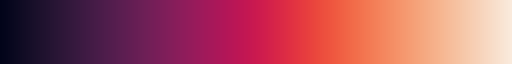

In [9]:
cmap = sns.color_palette("rocket", as_cmap=True)
cmap

<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_103883/2690018502.py:18: SyntaxWarning: invalid escape sequence '\m'
  ax2.set_ylabel('N$_\mathrm{QSO}$')
/tmp/ipykernel_103883/2690018502.py:26: SyntaxWarning: invalid escape sequence '\m'
  ax3.set_xlabel('N$_\mathrm{QSO}$')


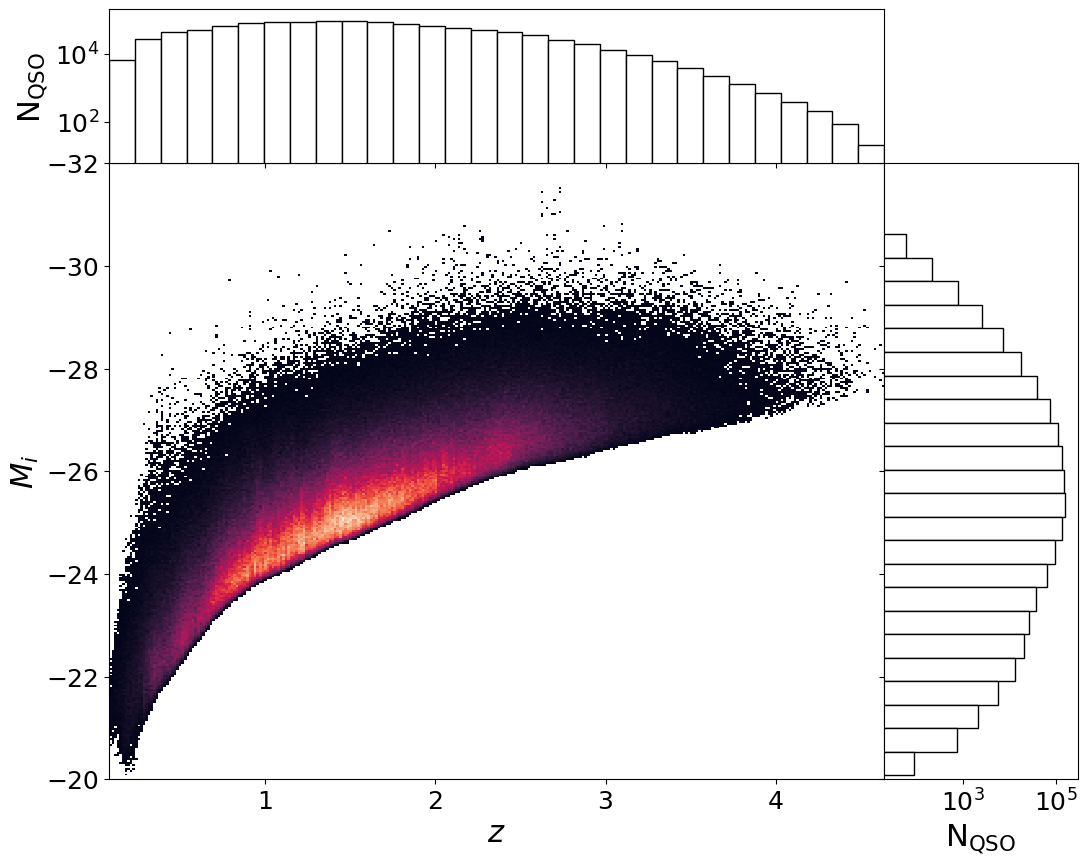

In [10]:
# plot!
fig = plt.figure(figsize = (12.5, 10))
gs = gridspec.GridSpec(2, 2, hspace = 0, height_ratios=[1,4], width_ratios=[4,1], wspace = 0)

ax1 = fig.add_subplot(gs[2])

quaia.absolute(tab_datahi, G_hi)
h1, xedges, yedges, image = ax1.hist2d(tab_datahi['redshift_quaia'][mask_datahi], tab_datahi['M_i'][mask_datahi], cmap = cmap, bins = 300, 
                                       cmin = 1)
ax1.set_ylabel('$M_i$')
ax1.set_xlabel('$z$')
ax1.set_ylim(-20, -32)
xlim = ax1.get_xlim()
ylim = ax1.get_ylim()

ax2 = fig.add_subplot(gs[0])
ax2.hist(tab_datahi['redshift_quaia'][mask_datahi], color = 'white', edgecolor = 'black', bins = 30)
ax2.set_ylabel('N$_\mathrm{QSO}$')
ax2.set_yscale('log')
ax2.set_xlim(xlim)
ax2.set_ylim(6,2e5)
ax2.set_xticklabels([])

ax3 = fig.add_subplot(gs[3])
ax3.hist(tab_datahi['M_i'][mask_datahi], color = 'white', edgecolor = 'black', orientation = 'horizontal', bins = 25)
ax3.set_xlabel('N$_\mathrm{QSO}$')
ax3.set_xscale('log')
ax3.set_yticklabels([])
ax3.set_ylim(ylim)
ax3.set_xlim(2e1,3e5)

plt.show()

# Compute clustering in joint L threshold and z bins
## $\xi(s)$

In [11]:
# Create the bins array
# offset = 5 #2.5
# delta_max = 20 #40
# delta_min = np.min((np.floor((30-0.15)/offset), delta_max))

rmin = 30 #30-delta_min*offset # 0.1 # start higher # 1.4 # 30
rmax = 180 #80 #80+delta_max*offset # 200
nbins = 30 #10 #int((rmax-rmin)/offset) #20 + int(delta_min+delta_max) #90 #20
rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'linear'
rbins, quaia.recenter(rbins), np.diff(quaia.recenter(rbins))

(array([ 30.,  35.,  40.,  45.,  50.,  55.,  60.,  65.,  70.,  75.,  80.,
         85.,  90.,  95., 100., 105., 110., 115., 120., 125., 130., 135.,
        140., 145., 150., 155., 160., 165., 170., 175., 180.]),
 array([ 32.5,  37.5,  42.5,  47.5,  52.5,  57.5,  62.5,  67.5,  72.5,
         77.5,  82.5,  87.5,  92.5,  97.5, 102.5, 107.5, 112.5, 117.5,
        122.5, 127.5, 132.5, 137.5, 142.5, 147.5, 152.5, 157.5, 162.5,
        167.5, 172.5, 177.5]),
 array([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.]))

In [12]:
zbin_array = [0.0,1.0,2.0,3.0,4.6]
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(zbin_array)-1))

In [13]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

## Pick cosmology

In [14]:
cosmo = 'Planck' #'Planck'

In [15]:
L_bins = np.array([-32.0, -27.0, -26.0, -25.0, -20.0])[:0:-1]
L_bins

array([-20., -25., -26., -27.])

<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:58: SyntaxWarning: invalid escape sequence '\l'
<>:59: SyntaxWarning: invalid escape sequence '\m'
<>:45: SyntaxWarning: invalid escape sequence '\l'
<>:58: SyntaxWarning: invalid escape sequence '\l'
<>:59: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_12254/2442761754.py:45: SyntaxWarning: invalid escape sequence '\l'
  ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]),
/tmp/ipykernel_12254/2442761754.py:58: SyntaxWarning: invalid escape sequence '\l'
  ax1.legend(loc = 'center right', bbox_to_anchor = (-0.15, 0.5), title = '$M_i\leq{}$'.format(L_bins[i]), title_fontsize = 18)
/tmp/ipykernel_12254/2442761754.py:59: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_ylabel('$N_\mathrm{QSO}$')


0.6894778799840835
Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0_Lmax-20.0: 0.31              224099 vs 324336


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.6998052036780241
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0_Lmax-20.0: 0.28              464321 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


...

/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.7825058063308259
Pixels masked by MC but not already by selfunc: 1036
G20.5_zmin2.0zmax3.0_Lmax-27.0: 0.35              66760 vs 103123


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


0.9260170066053528
Pixels masked by MC but not already by selfunc: 278
G20.5_zmin3.0zmax4.6_Lmax-27.0: 0.26              21578 vs 28981


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


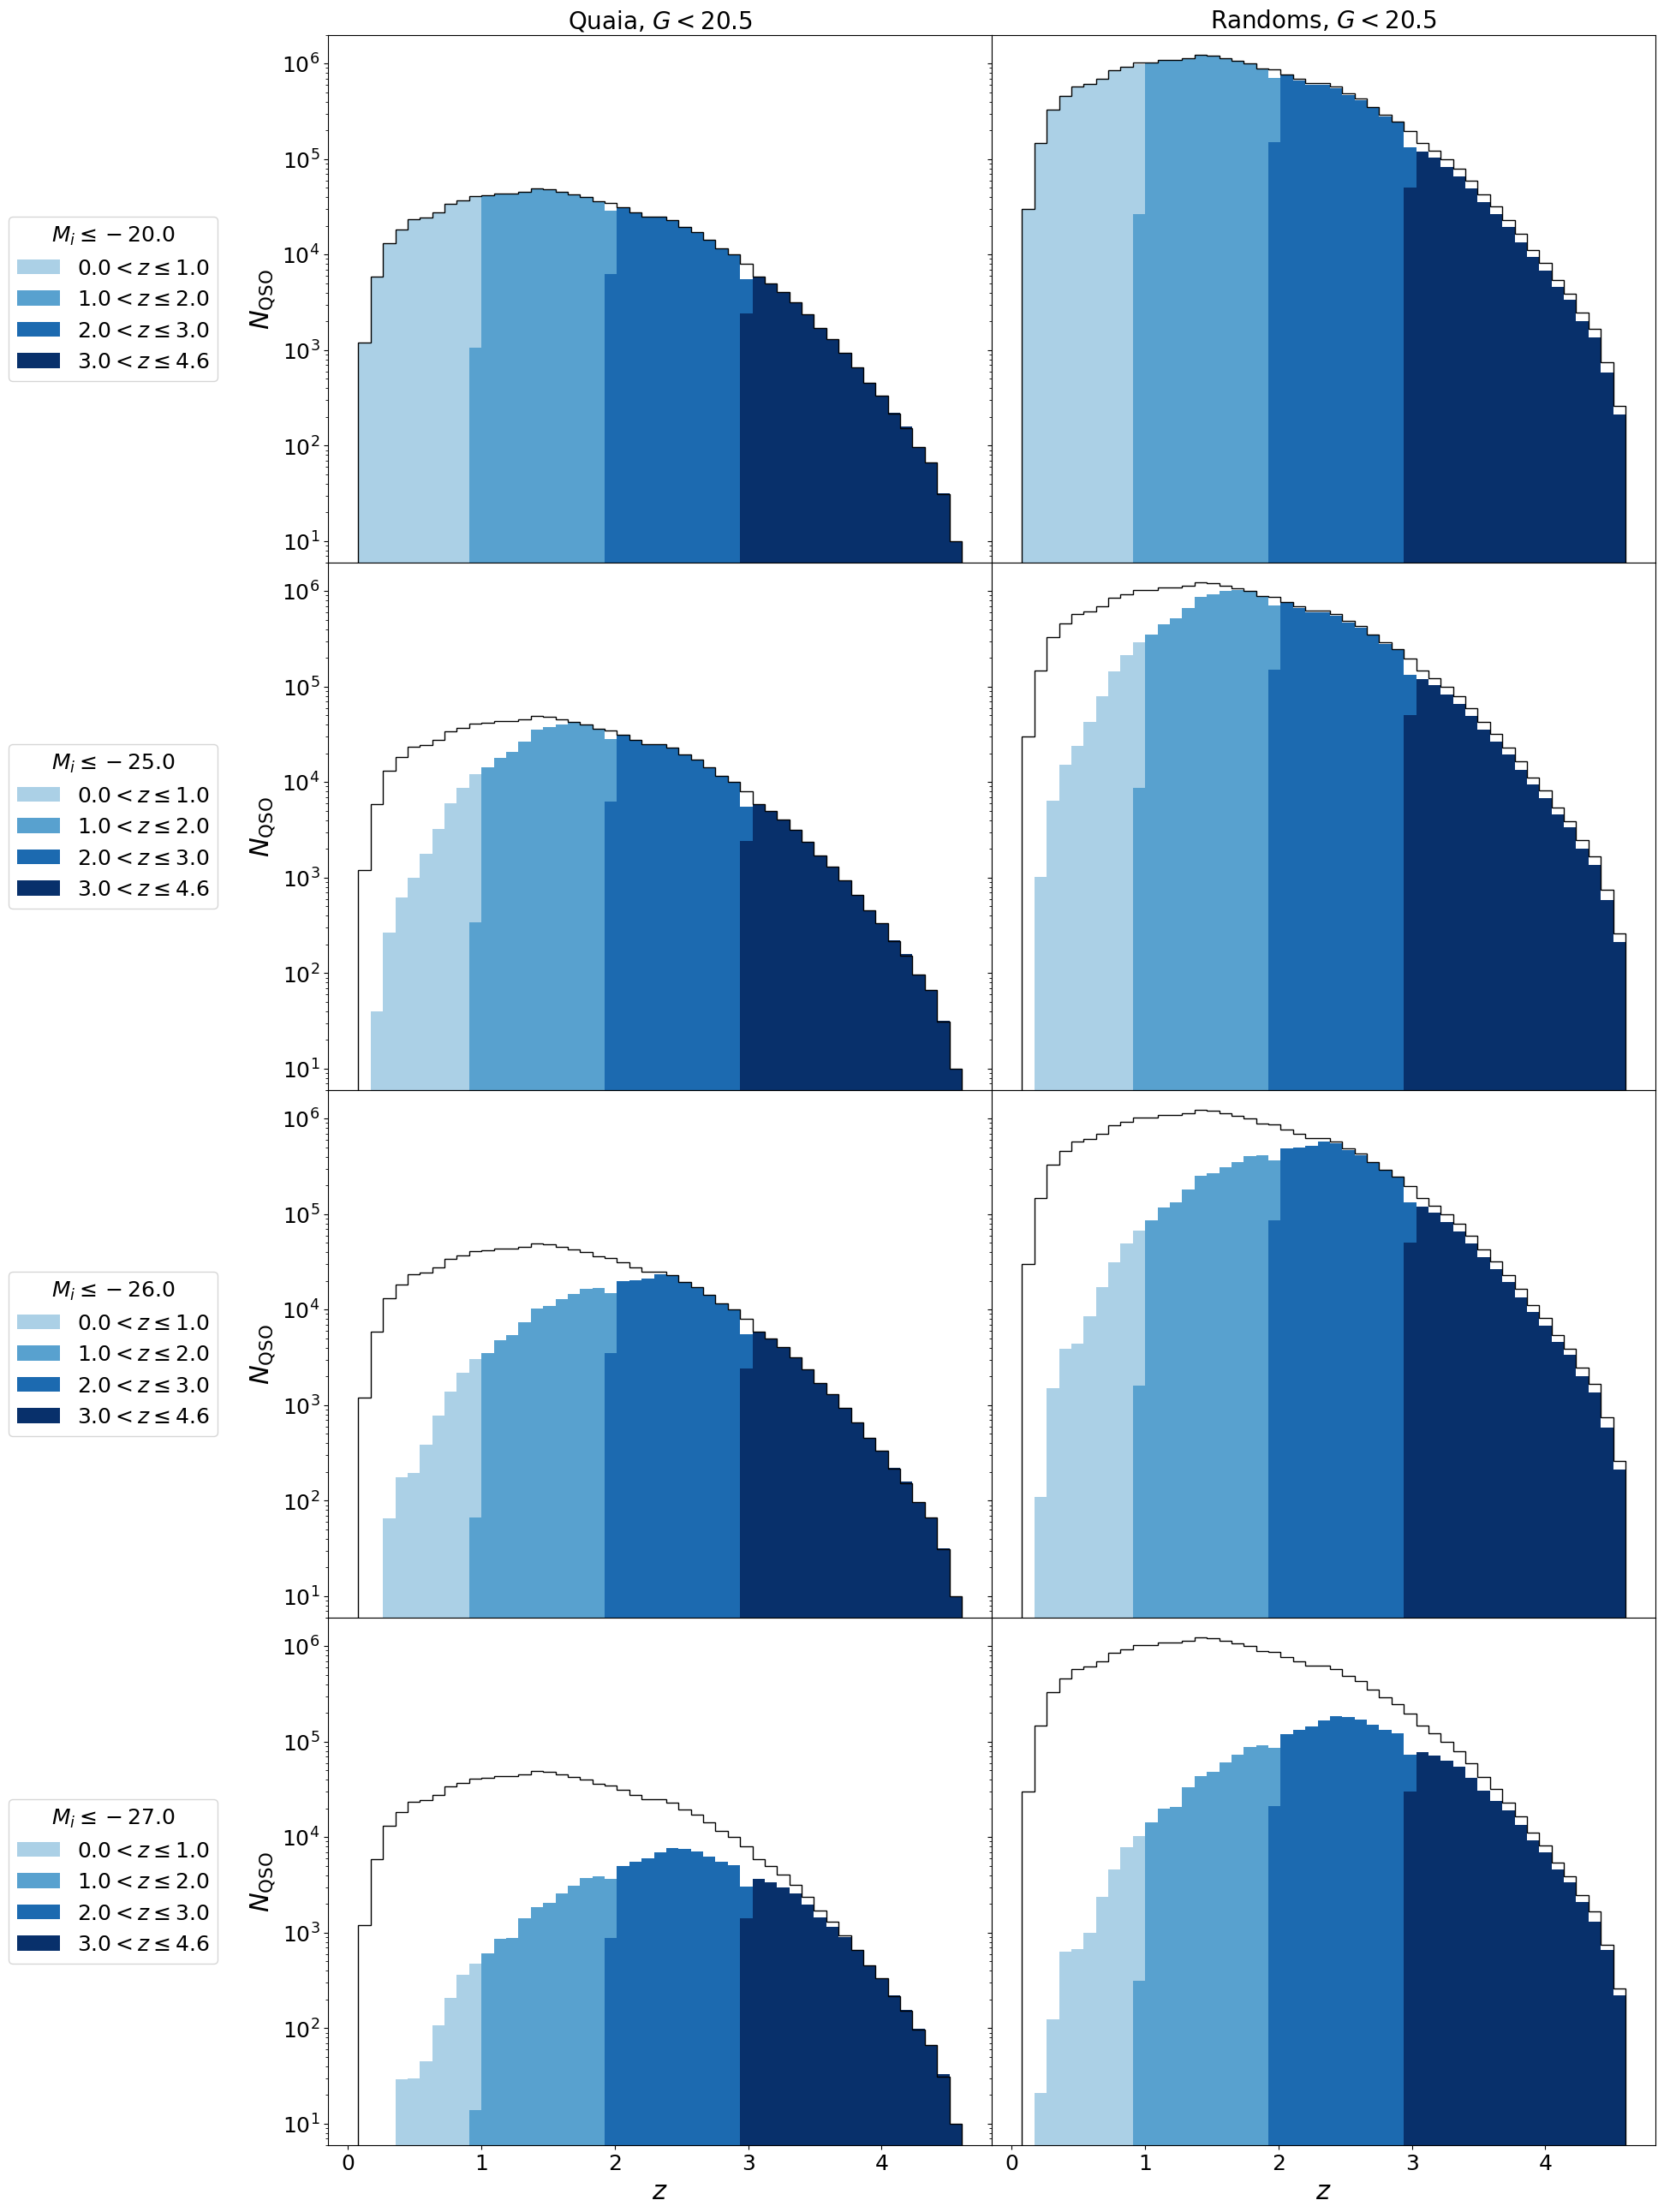

In [16]:
# plot data
bins = np.linspace(0.08, 4.6)
cf = {L: [] for L in L_bins}
fac_rand = 25
mask = 0.5
fn_selhi = '../data/maps/selection_function_NSIDE64_G{}.fits'.format(G_hi)
selfunc_hi = hp.fitsfunc.read_map(fn_selhi)

fn_datahi = '../data/quaia_G{}.fits'.format(G_hi)
tab_datahi = Table.read(fn_datahi)
pixel_indices_datahi = hp.ang2pix(NSIDE, tab_datahi['ra'], tab_datahi['dec'], lonlat=True)
mask_datahi = selfunc_hi[pixel_indices_datahi]>=np.percentile(selfunc_hi, mask*100)

# plot!
fig = plt.figure(figsize = (20, 32))
gs = gridspec.GridSpec(4, 2, wspace = 0, hspace = 0)

# for comparison purposes
fn_randhi = '../data/randoms/random_G{}_{}x.fits'.format(G_hi, fac_rand)
tab_randhi = Table.read(fn_randhi)
pixel_indices_randhi = hp.ang2pix(NSIDE, tab_randhi['ra'], tab_randhi['dec'], lonlat=True)
mask_randhi = selfunc_hi[pixel_indices_randhi]>=np.percentile(selfunc_hi, mask*100)
N_randhi_mask = len(tab_randhi['ra'][mask_randhi])
N_datahi_mask = len(tab_datahi['ra'][mask_datahi])
quaia.z_dist(tab_datahi, tab_randhi, mask_datahi, mask_randhi, N_datahi_mask, N_randhi_mask, mask_type = mask_type)

N_q = {L: [] for L in L_bins}
for i in range(len(L_bins)):
    
    ax1 = fig.add_subplot(gs[i*2])
    ax1.hist(tab_datahi['redshift_quaia'][mask_datahi], bins=bins, histtype = 'step', color='black')

    # plot randoms  
    ax2 = fig.add_subplot(gs[i*2+1])
    ax2.hist(tab_randhi['redshift_quaia_'+mask_type], histtype = 'step', bins = bins, 
         color = 'black')
        
    for j in range(len(zbin_array)-1):
        
        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, [j, i], True, ['z', 'L'], 
                                                                                             bins = [zbin_array, L_bins], tab_gcat_type = 'data', 
                                                                                              method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                              mask = mask*100, percentile = True, n_bins = [None, None])
        
        ax1.hist(tab_datahi_mask_zbin0['redshift_quaia'], label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]), 
                 bins = bins, color = cmap_blue[j])
        ax2.hist(tab_randhi_mask_zbin0['redshift_quaia_{}'.format(key_zbin0)], label = 'bin{}'.format(i),
                 bins = bins, color = cmap_blue[j])

        cf[L_bins[i]].append(quaia.xi_s(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, nthreads = nthreads, rbins = rbins, Om0 = Planck18.Om0, #Om0[cosmo], 
                                                      h = Planck18.h)) # h = h, Om0 = Omega_m_planck20))

        N_q[L_bins[i]].append(len(tab_datahi_mask_zbin0))

    ax1.set_xlabel('$z$')
    ax1.set_yscale('log')
    ax1.set_ylim(6,2e6)
    ax1.legend(loc = 'center right', bbox_to_anchor = (-0.15, 0.5), title = '$M_i\leq{}$'.format(L_bins[i]), title_fontsize = 18)
    ax1.set_ylabel('$N_\mathrm{QSO}$')

    ax2.set_xlabel('$z$')
    ax2.set_yscale('log')
    ax2.set_ylim(6,2e6)
    ax2.set_yticklabels([])
    
    if i == 0:
        ax1.set_title('Quaia, $G<{}$'.format(G_hi))
        ax2.set_title('Randoms, $G<{}$'.format(G_hi))
        
    if i < 3:
        ax1.set_xticklabels([])
        ax2.set_xticklabels([])
        
plt.show()

# Use delete-one jackknife resampling
## Split the sky into RA stripes

In [17]:
N = 50 #40 #20 #65 #50 #30 #15 #45 #85 #25 #10
ra_bins = np.linspace(0, 360, N+1)
for i in range(N): #-1):
    
    delete = (tab_datahi_mask_zbin0['ra']>=ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] <ra_bins[i])
    print(np.unique(np.digitize(tab_datahi_mask_zbin0['ra'][delete], ra_bins)))

[ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 42 43 44 45 46 47 48 49 50]
[ 1  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 42 43 44 45 46 47 48 49 50]
[ 1  2  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 42 43 44 45 46 47 48 49 50]
[ 1  2  3  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 42 43 44 45 46 47 48 49 50]
[ 1  2  3  4  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 42 43 44 45 46 47 48 49 50]
[ 1  2  3  4  5  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 42 43 44 45 46 47 48 49 50]
[ 1  2  3  4  5  6  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40

## Compute $\xi(s)$ in each jackknife bin

In [18]:
cf_jackknife = {Lbin: [] for Lbin in L_bins}

for k in range(len(L_bins)):

    for j in range(len(zbin_array)-1):

        tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _, _, _ = quaia.make_bins(G_hi, [j, k], True, ['z', 'L'], 
                                                                                             bins = [zbin_array, L_bins], tab_gcat_type = 'data', 
                                                                                              method = ['minmax', 'max'], fac_rand = fac_rand, 
                                                                                              mask = mask*100, percentile = True, n_bins = [None, None])

        cf_jackknife[L_bins[k]].append([])
        
        for i in trange(N): #len(ra_bins)-1):

            jackknife_data = (tab_datahi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_datahi_mask_zbin0['ra'] < ra_bins[i])
            jackknife_rand = (tab_randhi_mask_zbin0['ra'] >= ra_bins[i+1]) | (tab_randhi_mask_zbin0['ra'] < ra_bins[i])

            cf_jackknife[L_bins[k]][j].append(quaia.xi_s(tab_datahi_mask_zbin0[jackknife_data], tab_randhi_mask_zbin0[jackknife_rand], key_zbin0, 
                                                 nthreads = nthreads, rbins = rbins, Om0 = Planck18.Om0, #Om0[cosmo], 
                                                          h = Planck18.h)) # h = h, Om0 = Omega_m_planck20))
            # cf_jackknife[L_bins[k]][j].append([0,1])

0.6894778799840835
Pixels masked by MC but not already by selfunc: 1911
G20.5_zmin0.0zmax1.0_Lmax-20.0: 0.31              224099 vs 324336


  0%|          | 0/50 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 50/50 [52:02<00:00, 62.45s/it]


0.6998052036780241
Pixels masked by MC but not already by selfunc: 3700
G20.5_zmin1.0zmax2.0_Lmax-20.0: 0.28              464321 vs 648196


  0%|          | 0/50 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 50/50 [1:48:03<00:00, 129.68s/it]


0.7010382664550974
Pixels masked by MC but not already by selfunc: 3094
G20.5_zmin2.0zmax3.0_Lmax-20.0: 0.25              214535 vs 286508


...

  0%|          | 0/50 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 50/50 [01:40<00:00,  2.01s/it]


0.7825058063308259
Pixels masked by MC but not already by selfunc: 1036
G20.5_zmin2.0zmax3.0_Lmax-27.0: 0.35              66760 vs 103123


  0%|          | 0/50 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 50/50 [04:47<00:00,  5.74s/it]


0.9260170066053528
Pixels masked by MC but not already by selfunc: 278
G20.5_zmin3.0zmax4.6_Lmax-27.0: 0.26              21578 vs 28981


  0%|          | 0/50 [00:00<?, ?it/s]/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\
100%|██████████| 50/50 [01:25<00:00,  1.72s/it]


## Compute the jackknife covariance matrix
### \begin{array}{r}
C_{i j}=\frac{N-1}{N} \sum_{k=1}^N\left[\xi^{(k)}\left(s_{i}\right)-\bar{\xi}\left(s_{i}\right)\right] \\
{\left[\xi^{(k)}\left(s_{j}\right)-\bar{\xi}\left(s_{j}\right)\right]}
\end{array}

In [19]:
C = {Lbin: [] for Lbin in L_bins}

for i in range(len(L_bins)):
    
    for j in range(len(zbin_array)-1):

        cf_mean = np.nanmean(cf_jackknife[L_bins[i]][j], axis = 0)  # is it ok to ignore nan values?
        delta = cf_jackknife[L_bins[i]][j]-cf_mean
        C[L_bins[i]].append((N-1)/N*(delta.T @ delta))

## Save the full covariance matrix

In [20]:
for i in range(len(L_bins)):

    for j in range(len(zbin_array)-1):
    
        np.save('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask'.format(G_hi, rmin, rmax, nbins, zbin_array[j], zbin_array[j+1], L_bins[i], N, cosmo), C[L_bins[i]][j])

# Plot

In [21]:
offset = 0.3

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12254/2026871464.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(r+offset*j, cf[L_bins[j]][i], marker = 'o', label = '$M_i\leq{}$'.format(L_bins[j]),
/tmp/ipykernel_12254/2026871464.py:22: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))


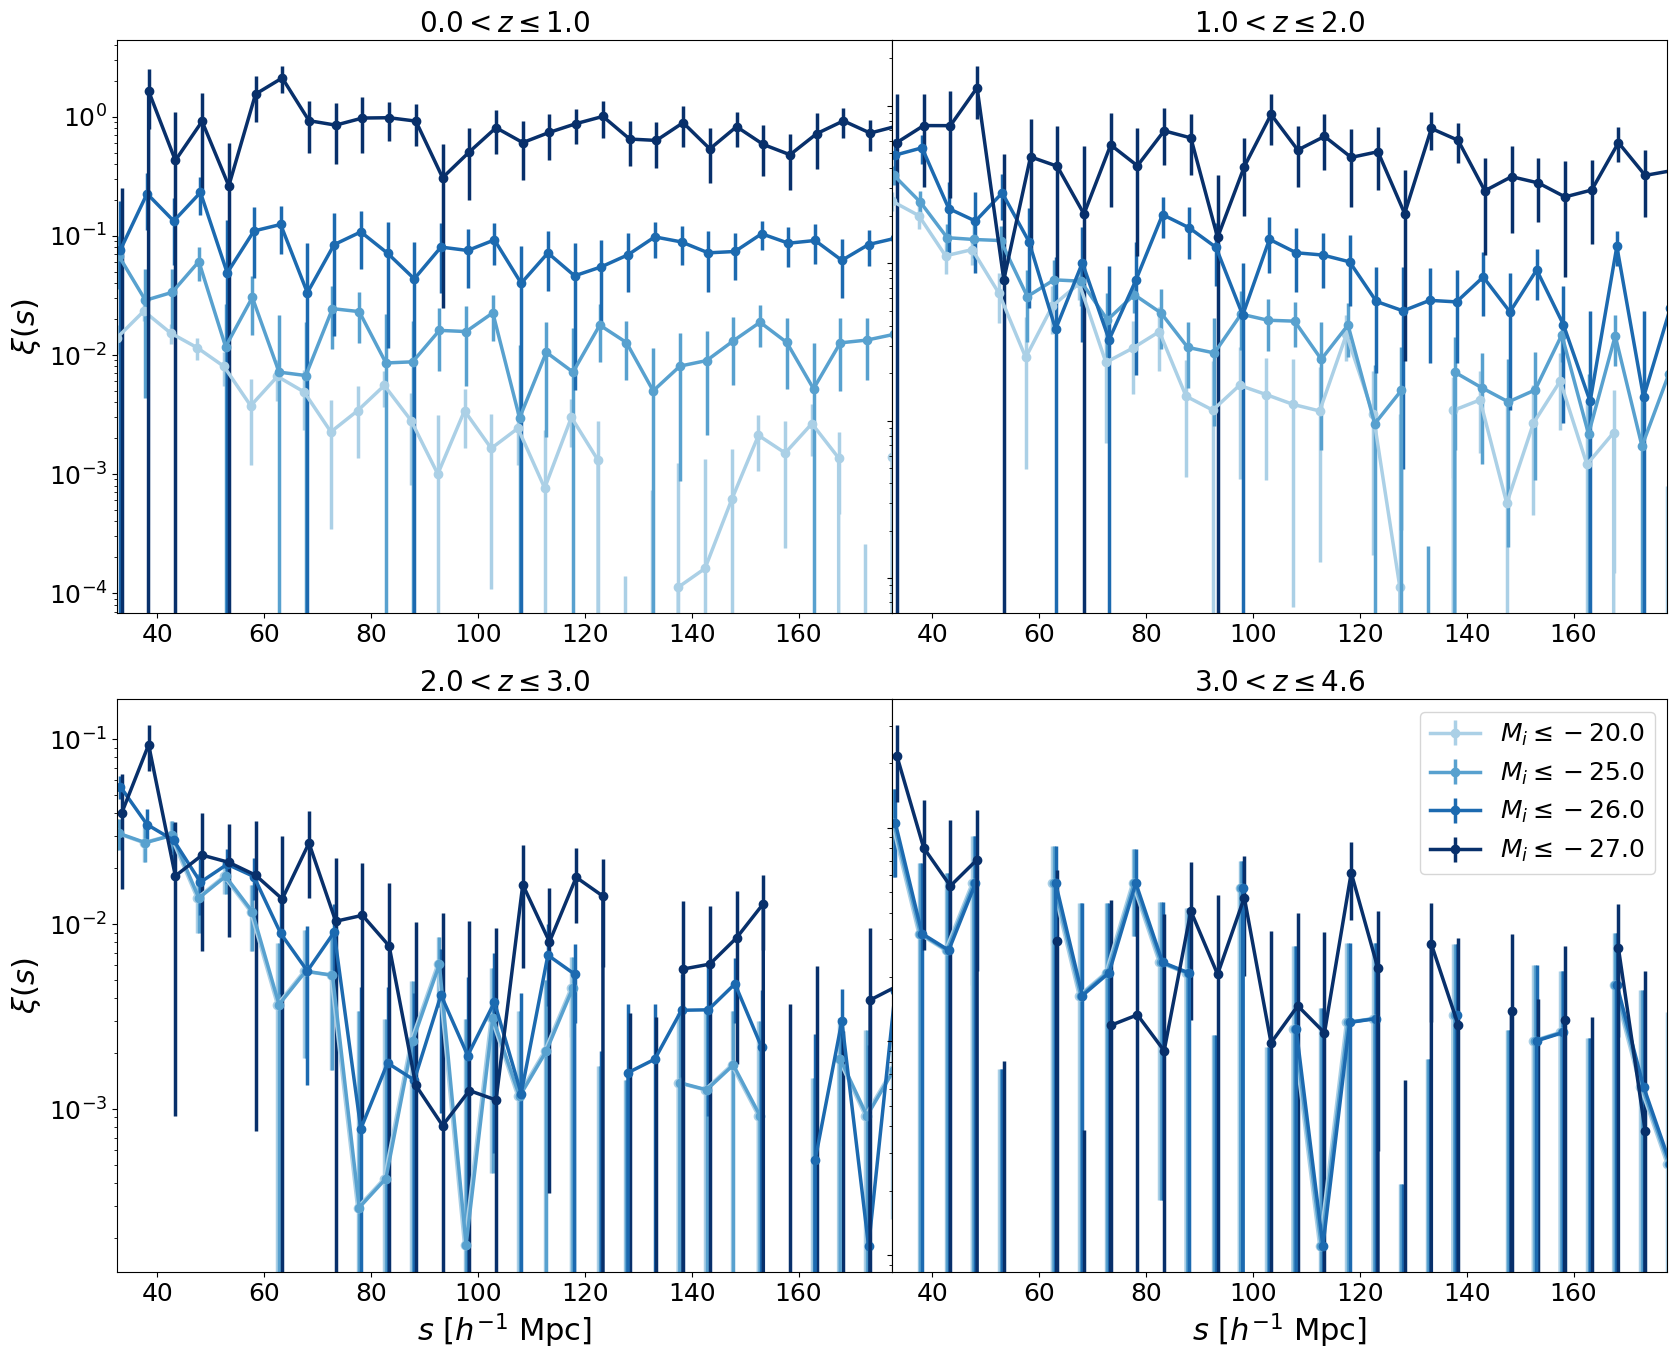

In [22]:
# plot!
r = quaia.recenter(rbins) #_chi2)

fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

for i in range(len(zbin_array)-1):

    ax1 = fig.add_subplot(gs[i])

    for j in range(len(L_bins)):

        sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo))))
        ax1.errorbar(r+offset*j, cf[L_bins[j]][i], marker = 'o', label = '$M_i\leq{}$'.format(L_bins[j]), 
                 linewidth = 2.5, color = cmap_blue[j], yerr = sigma) #np.sqrt(np.diag(C[zbin])))
    if i>1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
    if scale == 'log':
        ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(r[0], r[-1])
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))
    if i%2!=0:
        ax1.set_yticklabels([])
    else:
        ax1.set_ylabel(r"$\xi(s)$")
        
ax1.legend()
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:26: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12254/1823835682.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(r+offset*i, cf[L_bins[j]][i], marker = 'o', label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]),
/tmp/ipykernel_12254/1823835682.py:26: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))


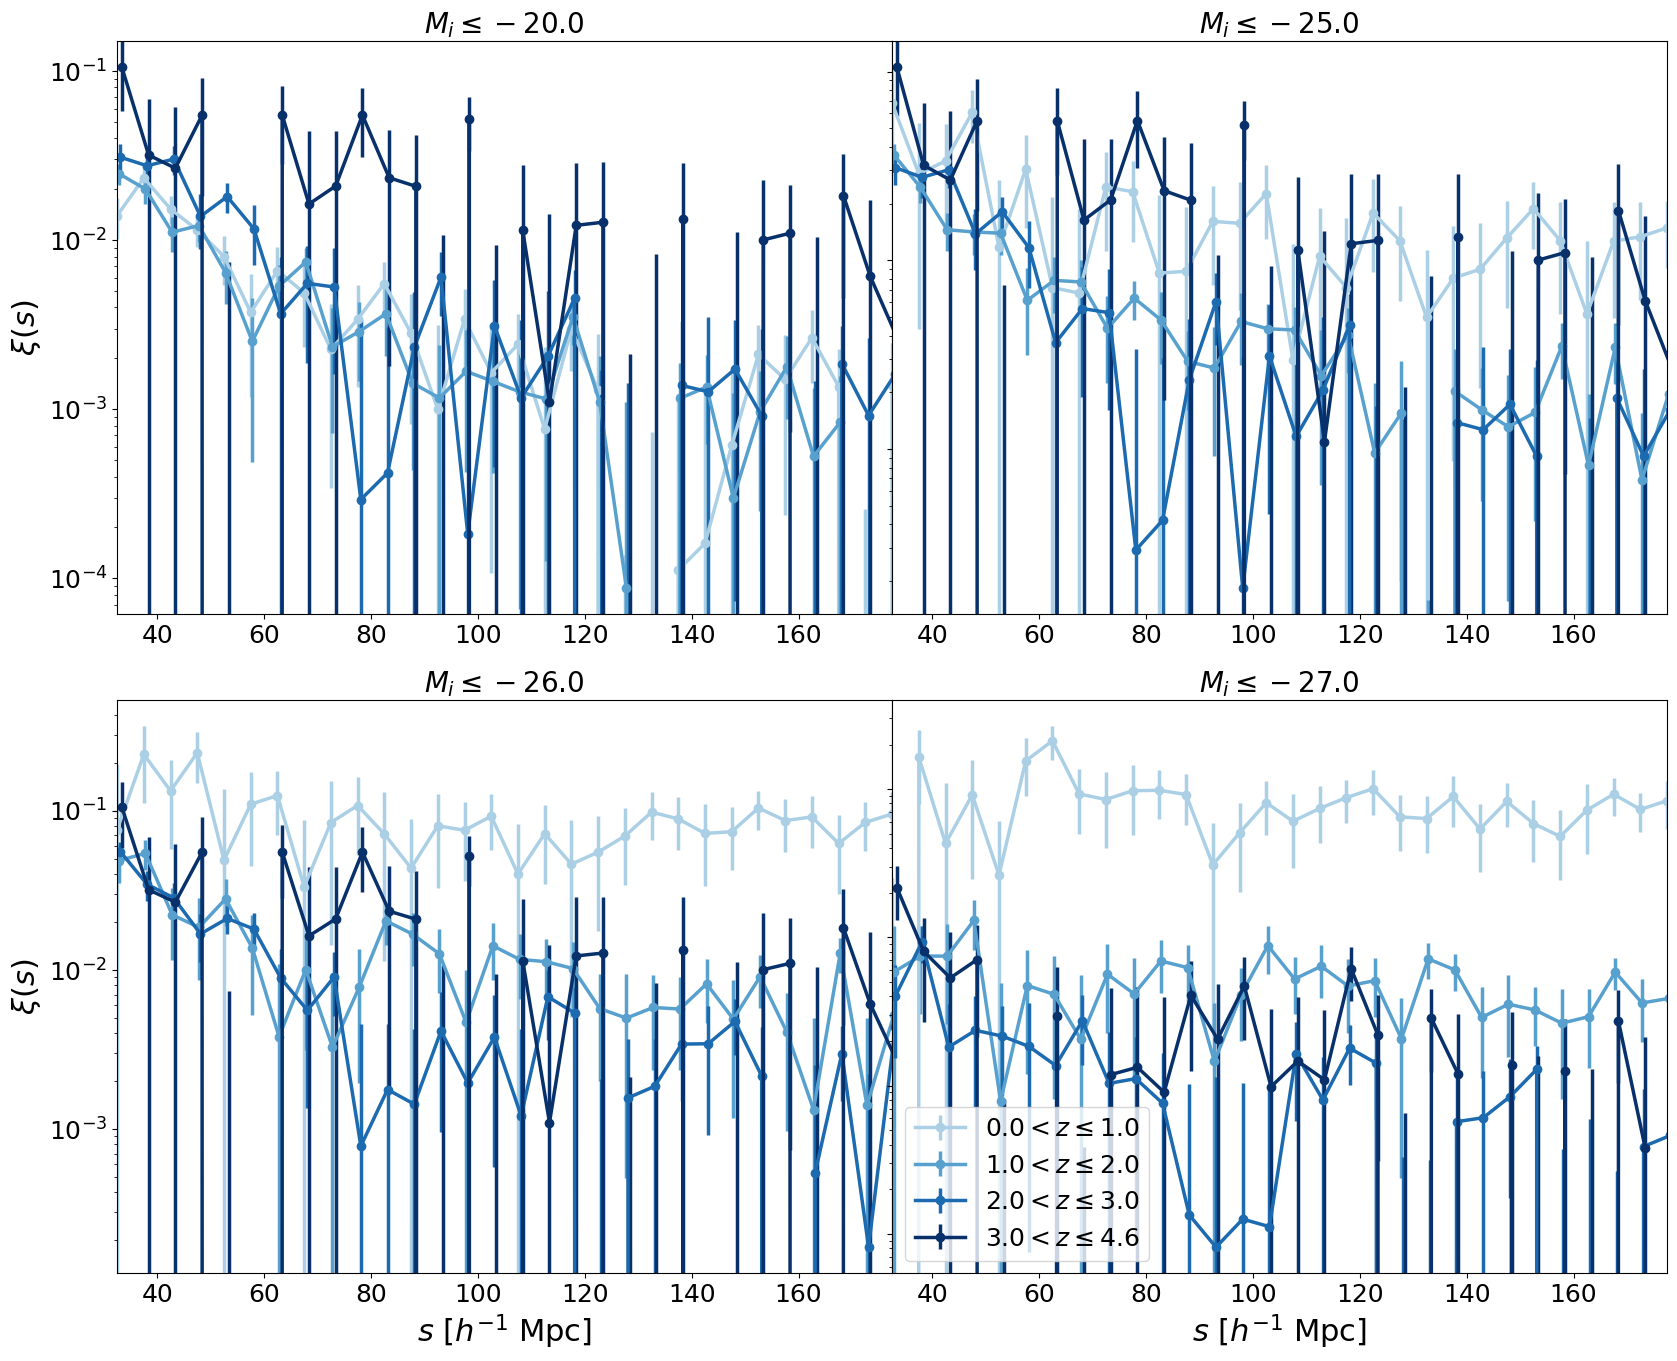

In [23]:
# plot!
r = quaia.recenter(rbins) #_chi2)

fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, wspace = 0, hspace = 0.15)

for j in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[j])

    for i in range(len(zbin_array)-1):

        sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo))))
        ax1.errorbar(r+offset*i, cf[L_bins[j]][i], marker = 'o', label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]), 
                 linewidth = 2.5, color = cmap_blue[i], yerr = sigma) #np.sqrt(np.diag(C[zbin])))
        if j>1:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(r[0], r[-1])
        if j%2!=0:
            ax1.set_yticklabels([])
        else:
            ax1.set_ylabel(r"$\xi(s)$")
        ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))

ax1.legend()
plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12254/2655799814.py:12: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(r, cf[L_bins[j]][i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]),
/tmp/ipykernel_12254/2655799814.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))


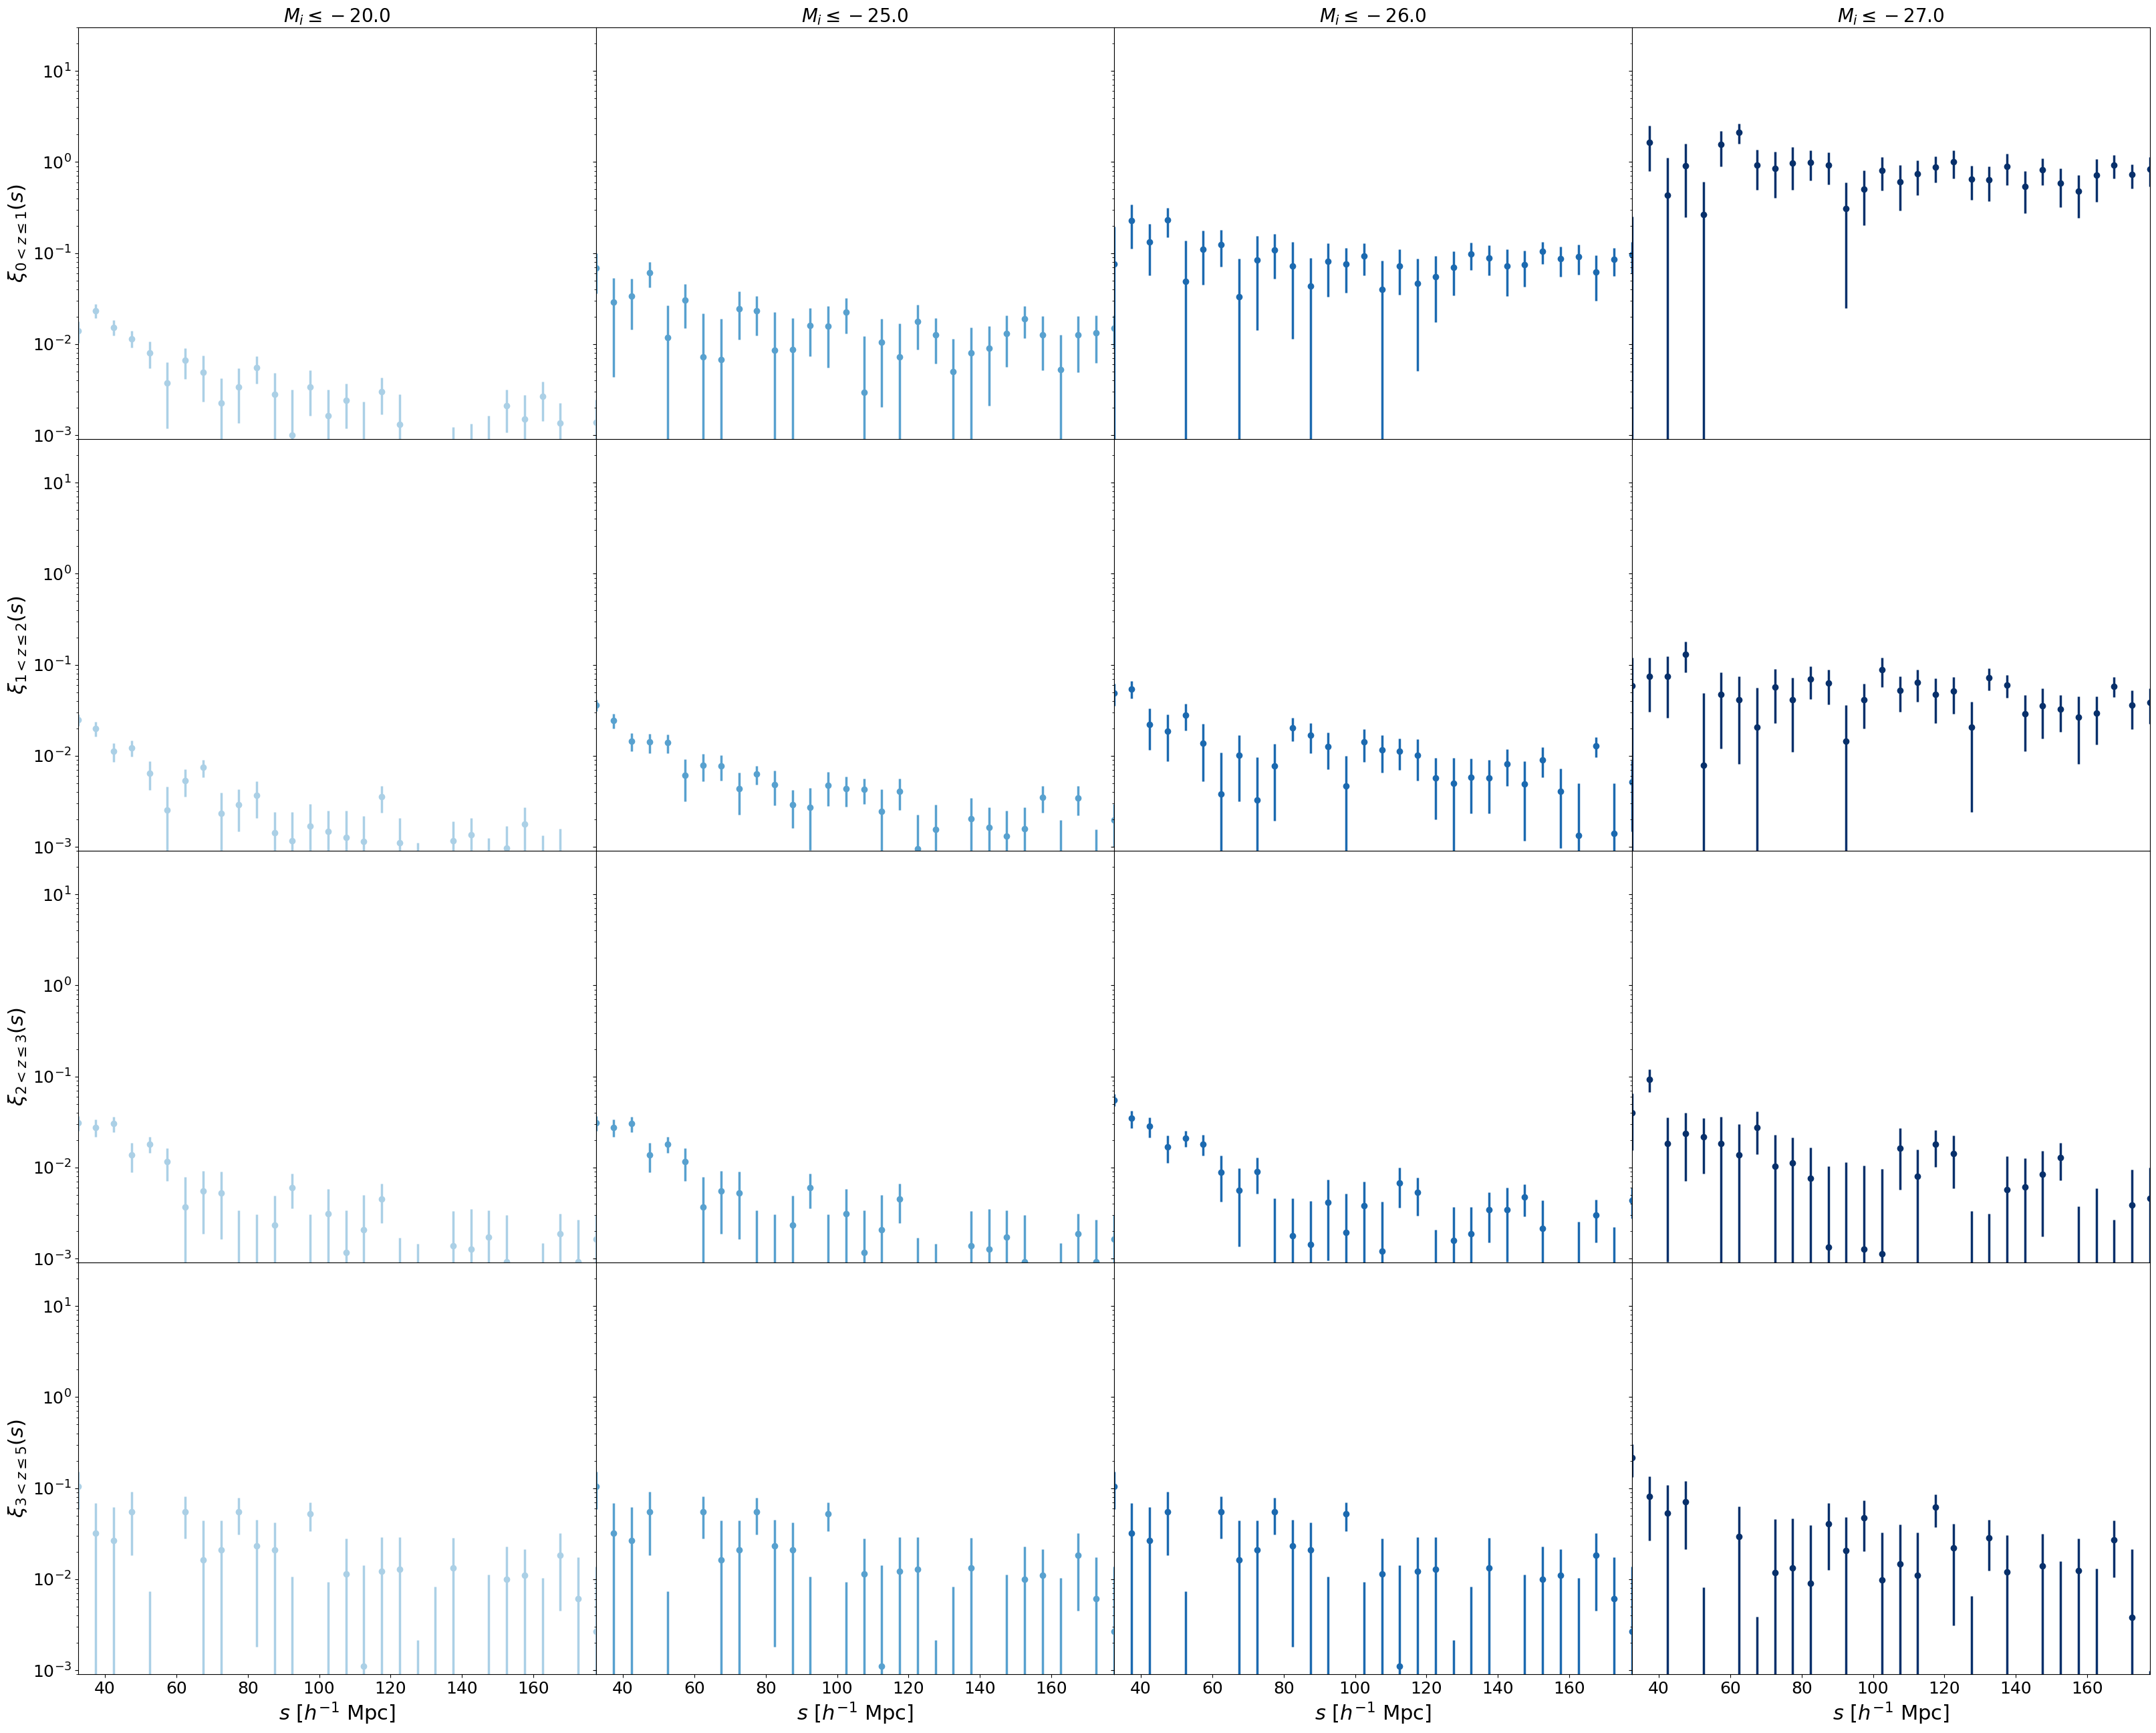

In [24]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)

for i in range(len(zbin_array)-1):
    
    for j in range(len(L_bins)):
    
        ax1 = fig.add_subplot(gs[i*4+j])

        sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo))))
        ax1.errorbar(r, cf[L_bins[j]][i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]), 
                 linewidth = 2.5, color = cmap_blue[j], yerr = sigma, linestyle = 'None')

        if i ==0:
            ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(r[0], r[-1])
        ax1.set_ylim(9e-4, 3e1)
        if i > 2:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if j==0:
            ax1.set_ylabel(r"$\xi_{{{:.0f}<z \leq{:.0f}}}(s)$".format(zbin_array[i], zbin_array[i+1]))
        else:
            ax1.set_yticklabels([])

plt.show()

<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:12: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12254/2501483421.py:12: SyntaxWarning: invalid escape sequence '\l'
  ax1.errorbar(r, cf[L_bins[j]][i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]),
/tmp/ipykernel_12254/2501483421.py:16: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))


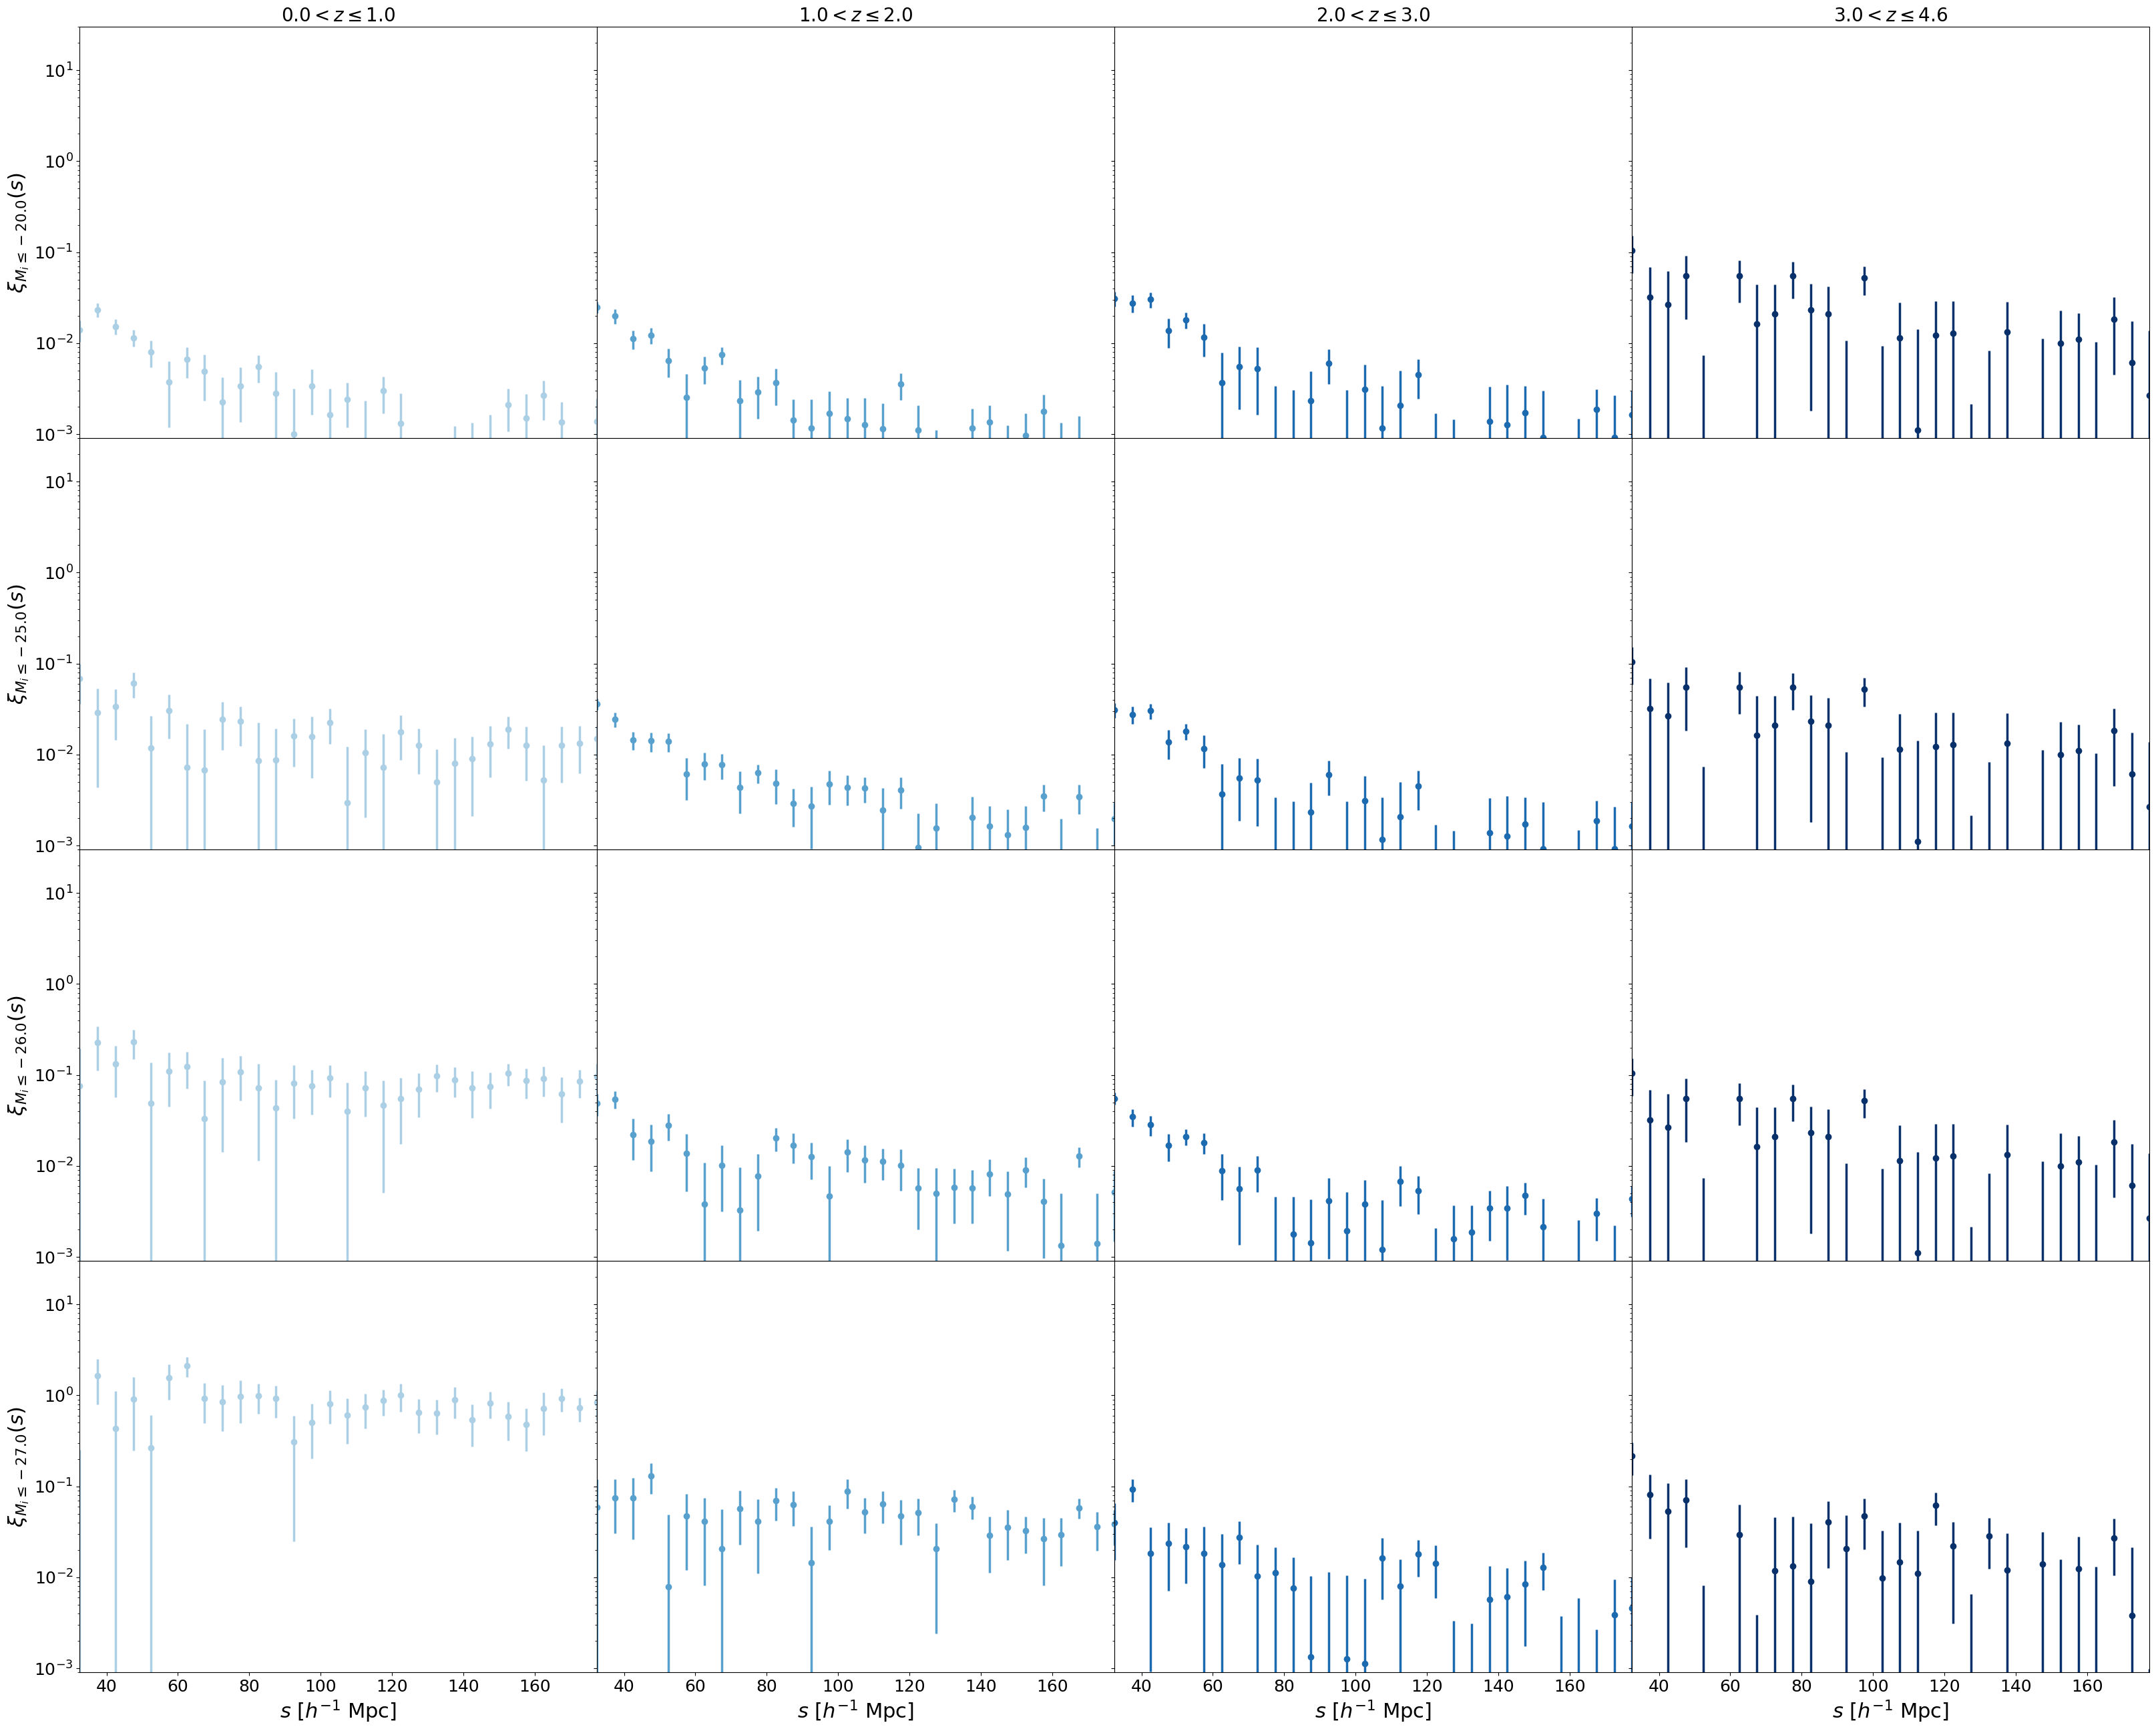

In [25]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0)

for j in range(len(L_bins)):

    for i in range(len(zbin_array)-1):
        
        ax1 = fig.add_subplot(gs[j*4+i])

        sigma = np.sqrt(np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo))))
        ax1.errorbar(r, cf[L_bins[j]][i], marker = 'o', label = '${:.0f}<z \leq{:.0f}$'.format(zbin_array[i], zbin_array[i+1]), 
                 linewidth = 2.5, color = cmap_blue[i], yerr = sigma, linestyle = 'None')

        if j ==0:
            ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))
        if scale == 'log':
            ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(r[0], r[-1])
        ax1.set_ylim(9e-4, 3e1)
        if j > 2:
            ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
        else: 
            ax1.set_xticklabels([])
        if i==0:
            ax1.set_ylabel(r"$\xi_{{M_i\leq{}}}(s)$".format(L_bins[j]))
        else:
            ax1.set_yticklabels([])

plt.show()

## Plot correlation matrix

<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\l'
<>:25: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12254/850384708.py:22: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_ylabel('$s_{{{:.1f}<z \leq{:.1f}}} (h^{{-1}}$ Mpc)'.format(zbin_array[i], zbin_array[i+1]))
/tmp/ipykernel_12254/850384708.py:25: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))


(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)
(-1.0, 1.0)


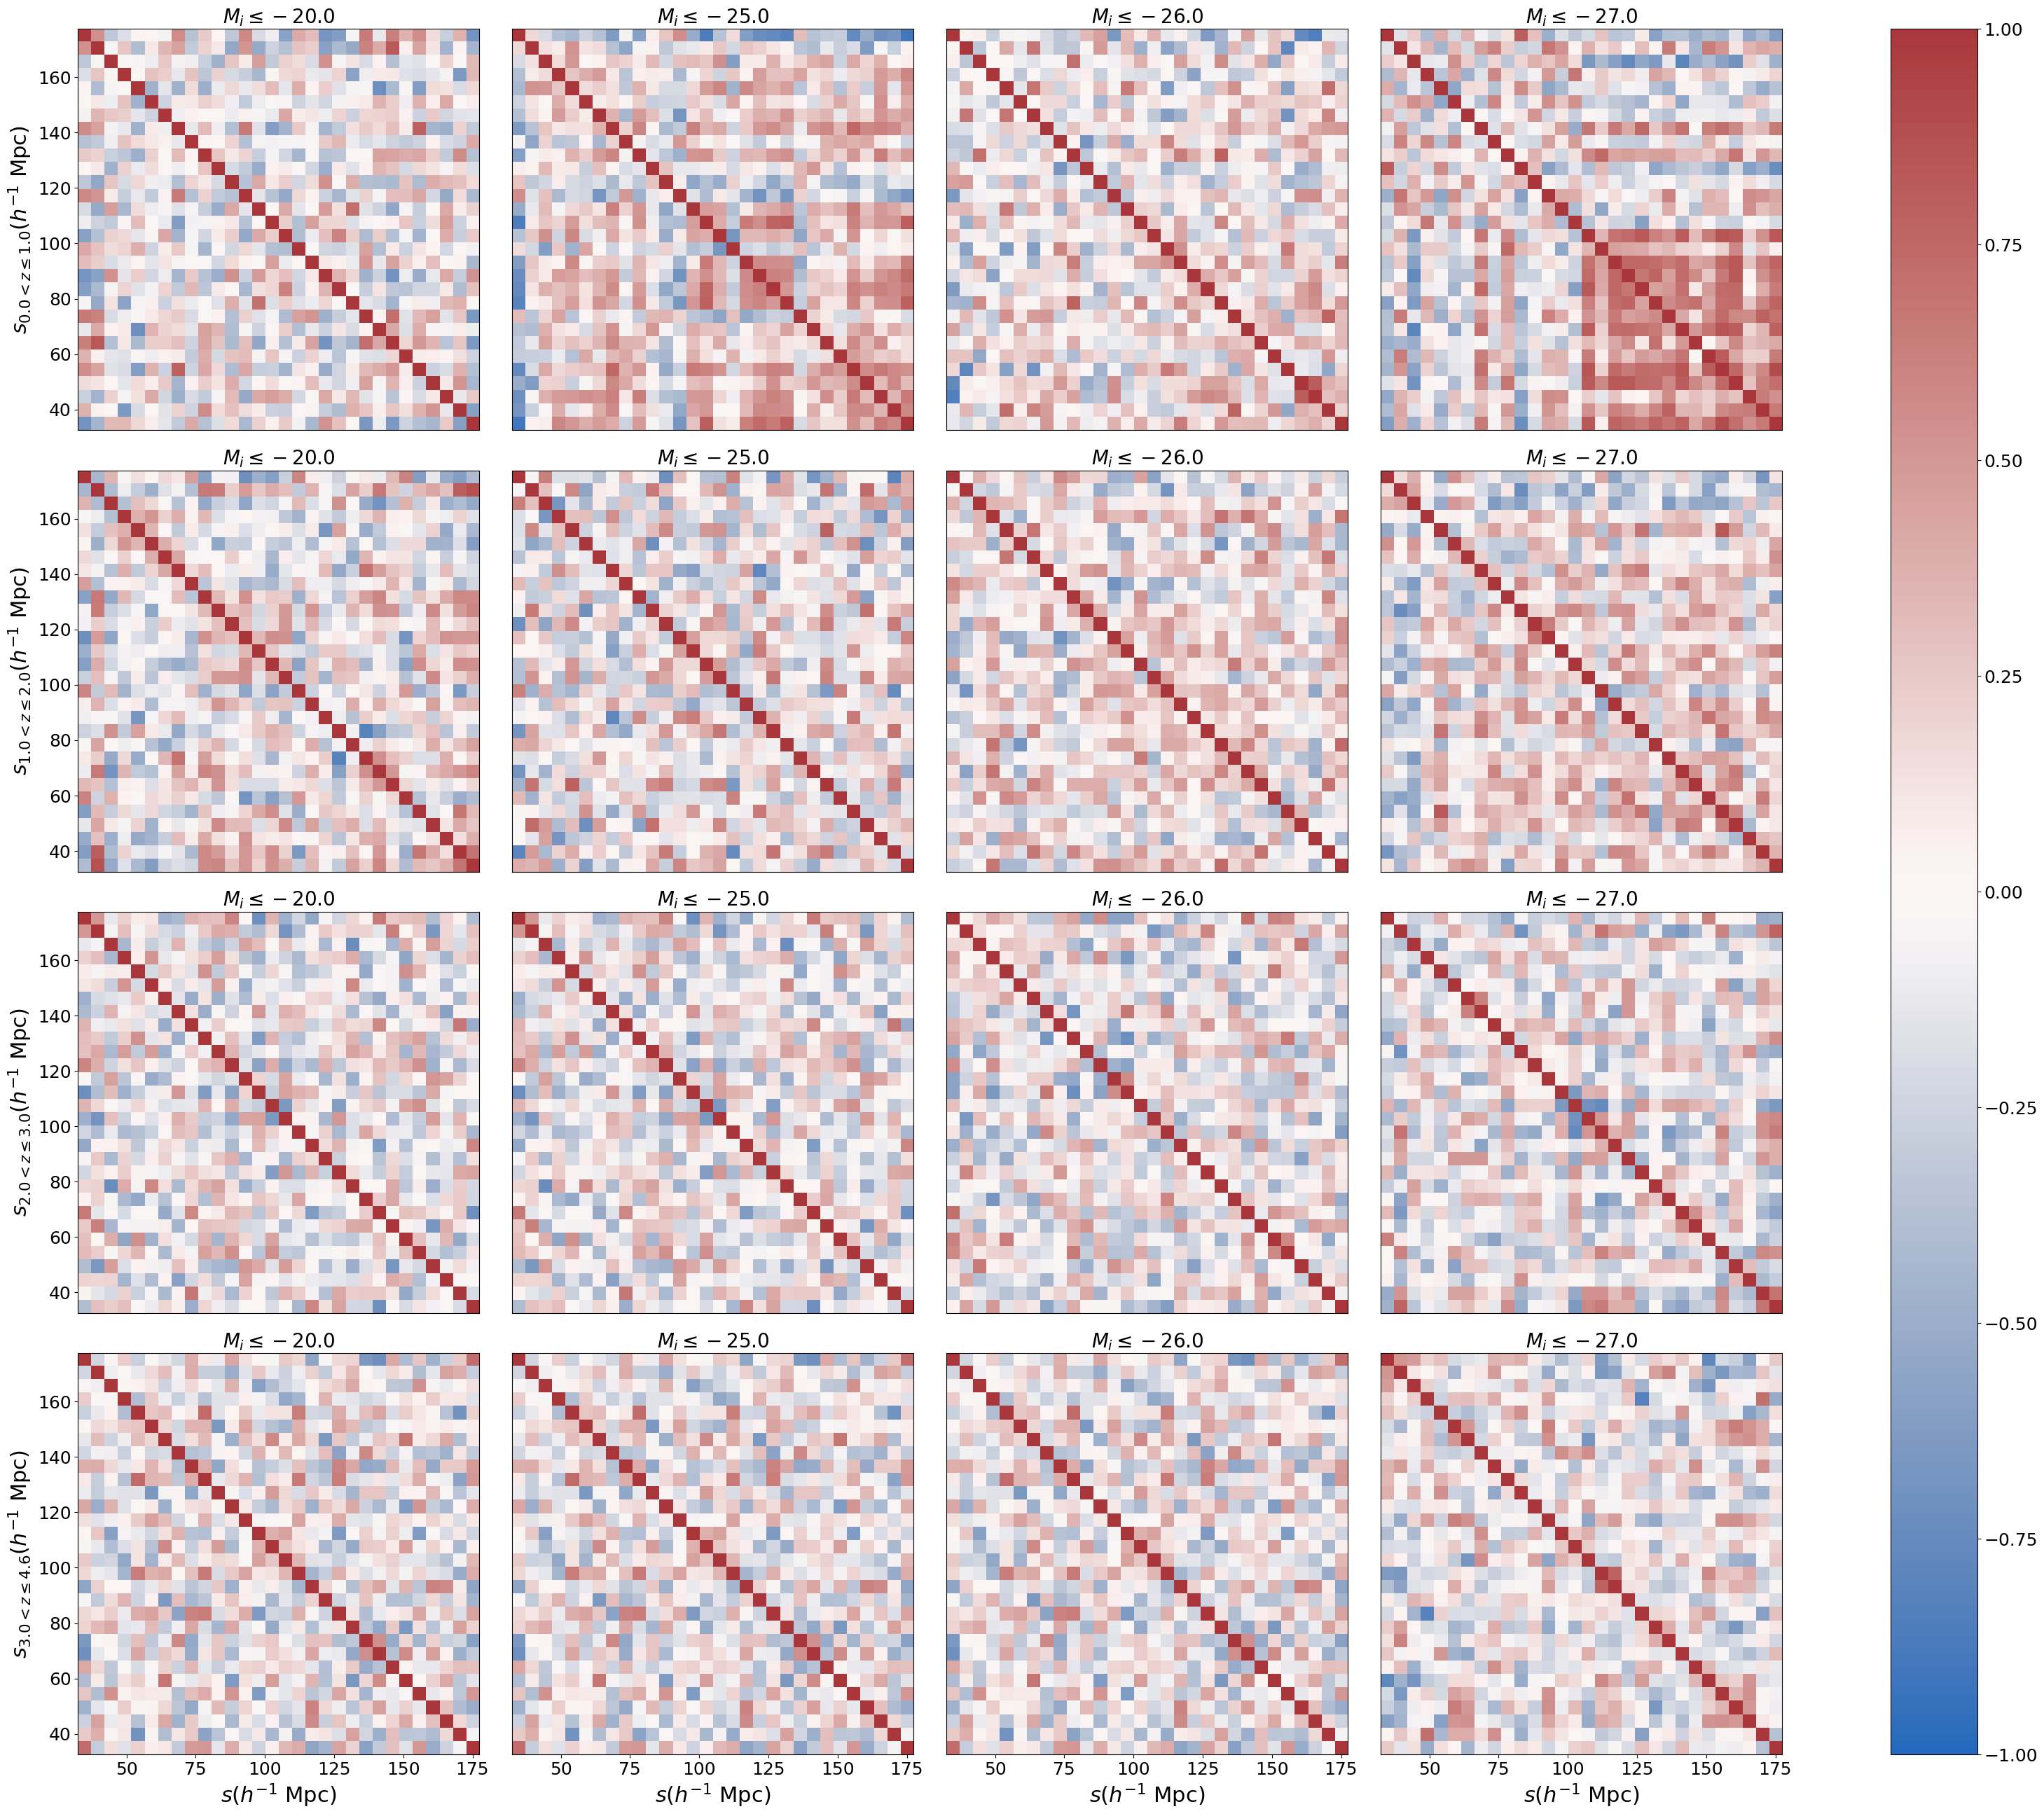

In [26]:
cmap = sns.color_palette("vlag", as_cmap=True)

# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)
axes = []
for i in range(len(zbin_array)-1):
    
    for j in range(len(L_bins)):
    
        ax1 = fig.add_subplot(gs[i*4+j])

        C = np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo))
        matrix = np.corrcoef(C)
        image = ax1.imshow(matrix, cmap = cmap, extent = [r[0], r[-1], r[0], r[-1]], vmin = -1, vmax = 1)
        print(image.get_clim())
        if i > 2:
            ax1.set_xlabel('$s (h^{-1}$ Mpc)')
        else:
            ax1.set_xticks([])
        if j == 0:
            ax1.set_ylabel('$s_{{{:.1f}<z \leq{:.1f}}} (h^{{-1}}$ Mpc)'.format(zbin_array[i], zbin_array[i+1]))
        else:
            ax1.set_yticks([])
        ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))
        axes.append(ax1)
    
fig.colorbar(image, ax = axes)
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12254/1000483919.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(r, var, linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[i])
/tmp/ipykernel_12254/1000483919.py:22: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma^2$')
/tmp/ipykernel_12254/1000483919.py:27: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]))


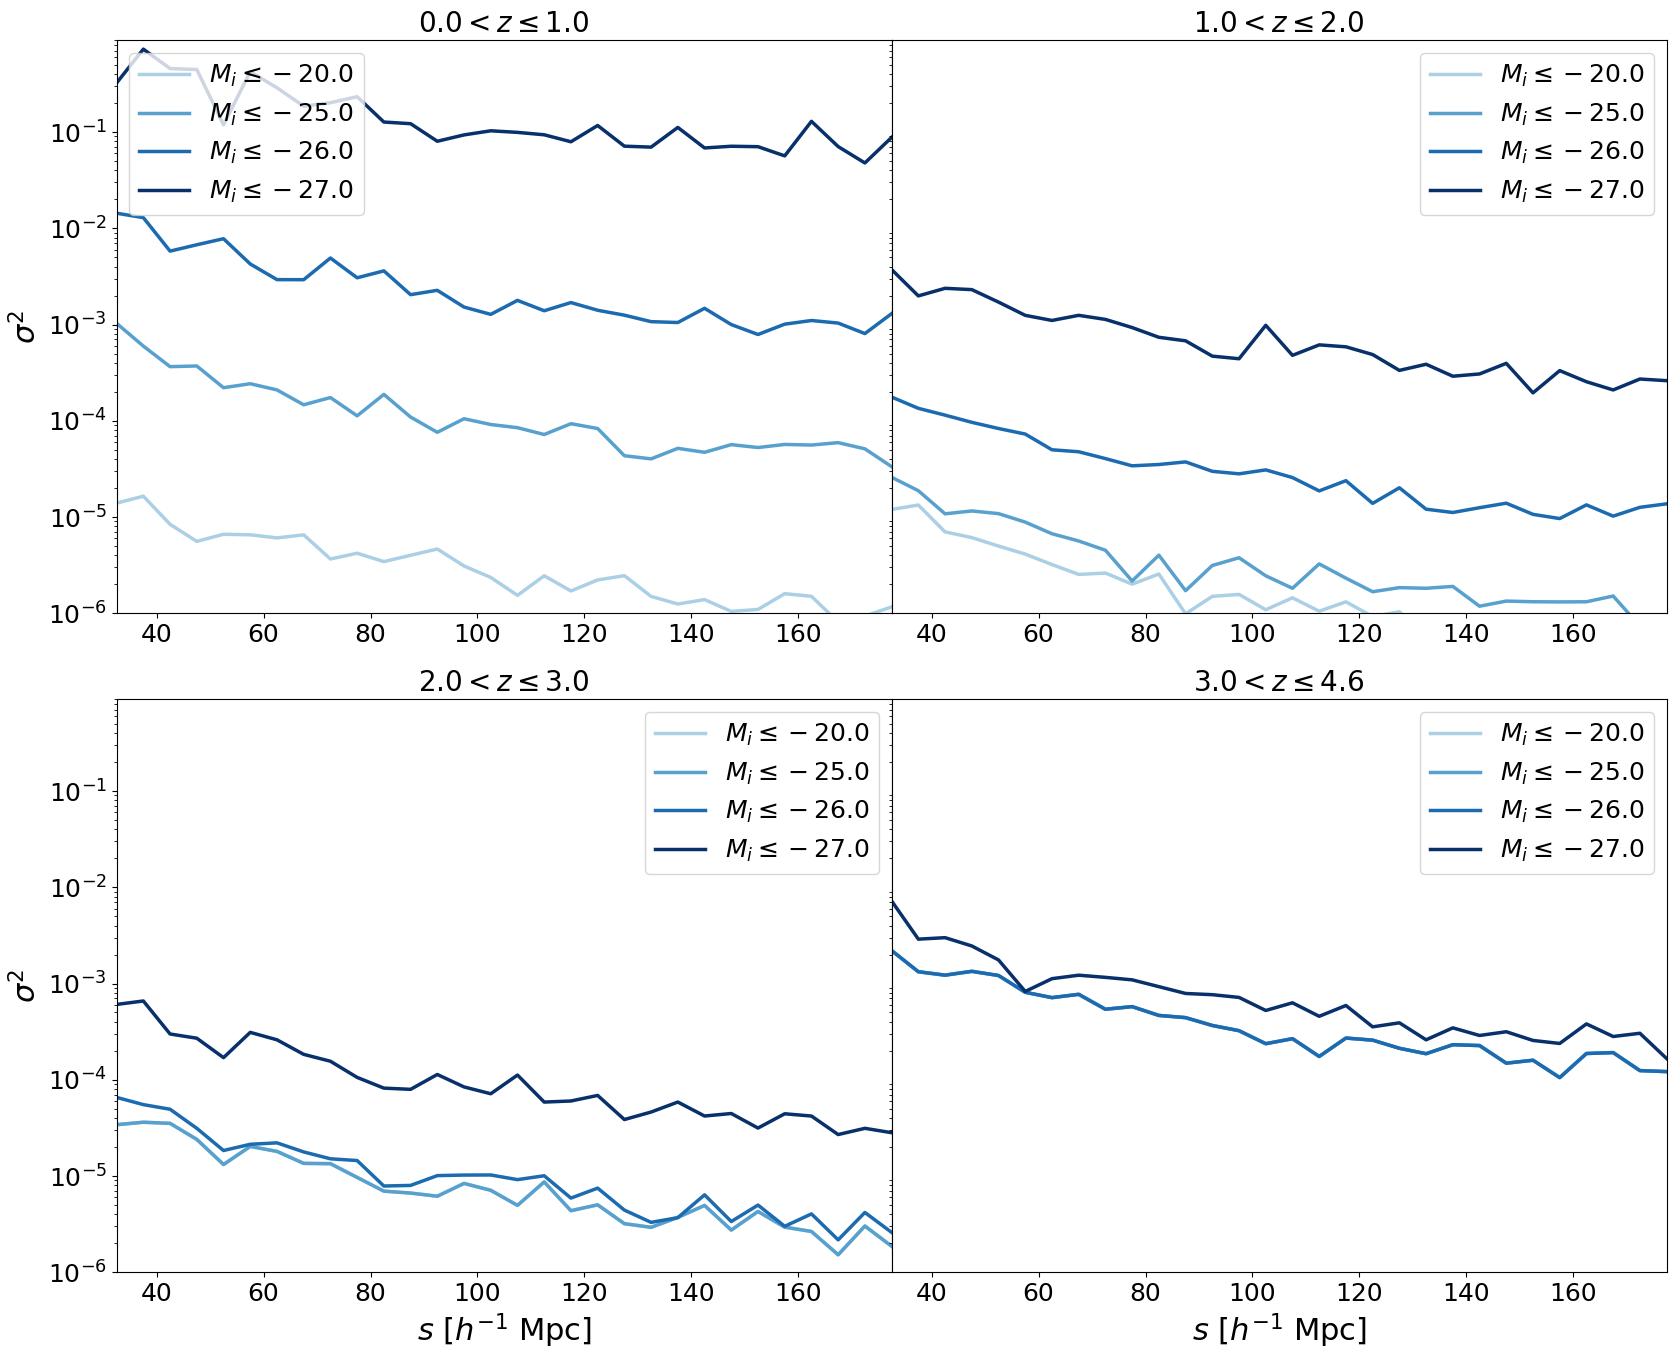

In [27]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for j in range(len(zbin_array)-1):

    ax1 = fig.add_subplot(gs[j])

    for i in range(len(L_bins)):

        # if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

        var = np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[j], zbin_array[j+1], L_bins[i], N, cosmo)))
        ax1.plot(r, var, linewidth = 2.5, label = '$M_i\leq{}$'.format(L_bins[i]), color = cmap_blue[i])

    ax1.set_xlim(r[0], r[-1])
    ax1.set_yscale('log')

    if j > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') #
            
    if j %2 ==0:
        ax1.set_ylabel('$\sigma^2$')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(1e-6, 9e-1)
    ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]))

    ax1.legend()
        
plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:13: SyntaxWarning: invalid escape sequence '\l'
<>:22: SyntaxWarning: invalid escape sequence '\s'
<>:27: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12254/3651805781.py:13: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(r, var, linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]), color = cmap_blue[j])
/tmp/ipykernel_12254/3651805781.py:22: SyntaxWarning: invalid escape sequence '\s'
  ax1.set_ylabel('$\sigma$')
/tmp/ipykernel_12254/3651805781.py:27: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))


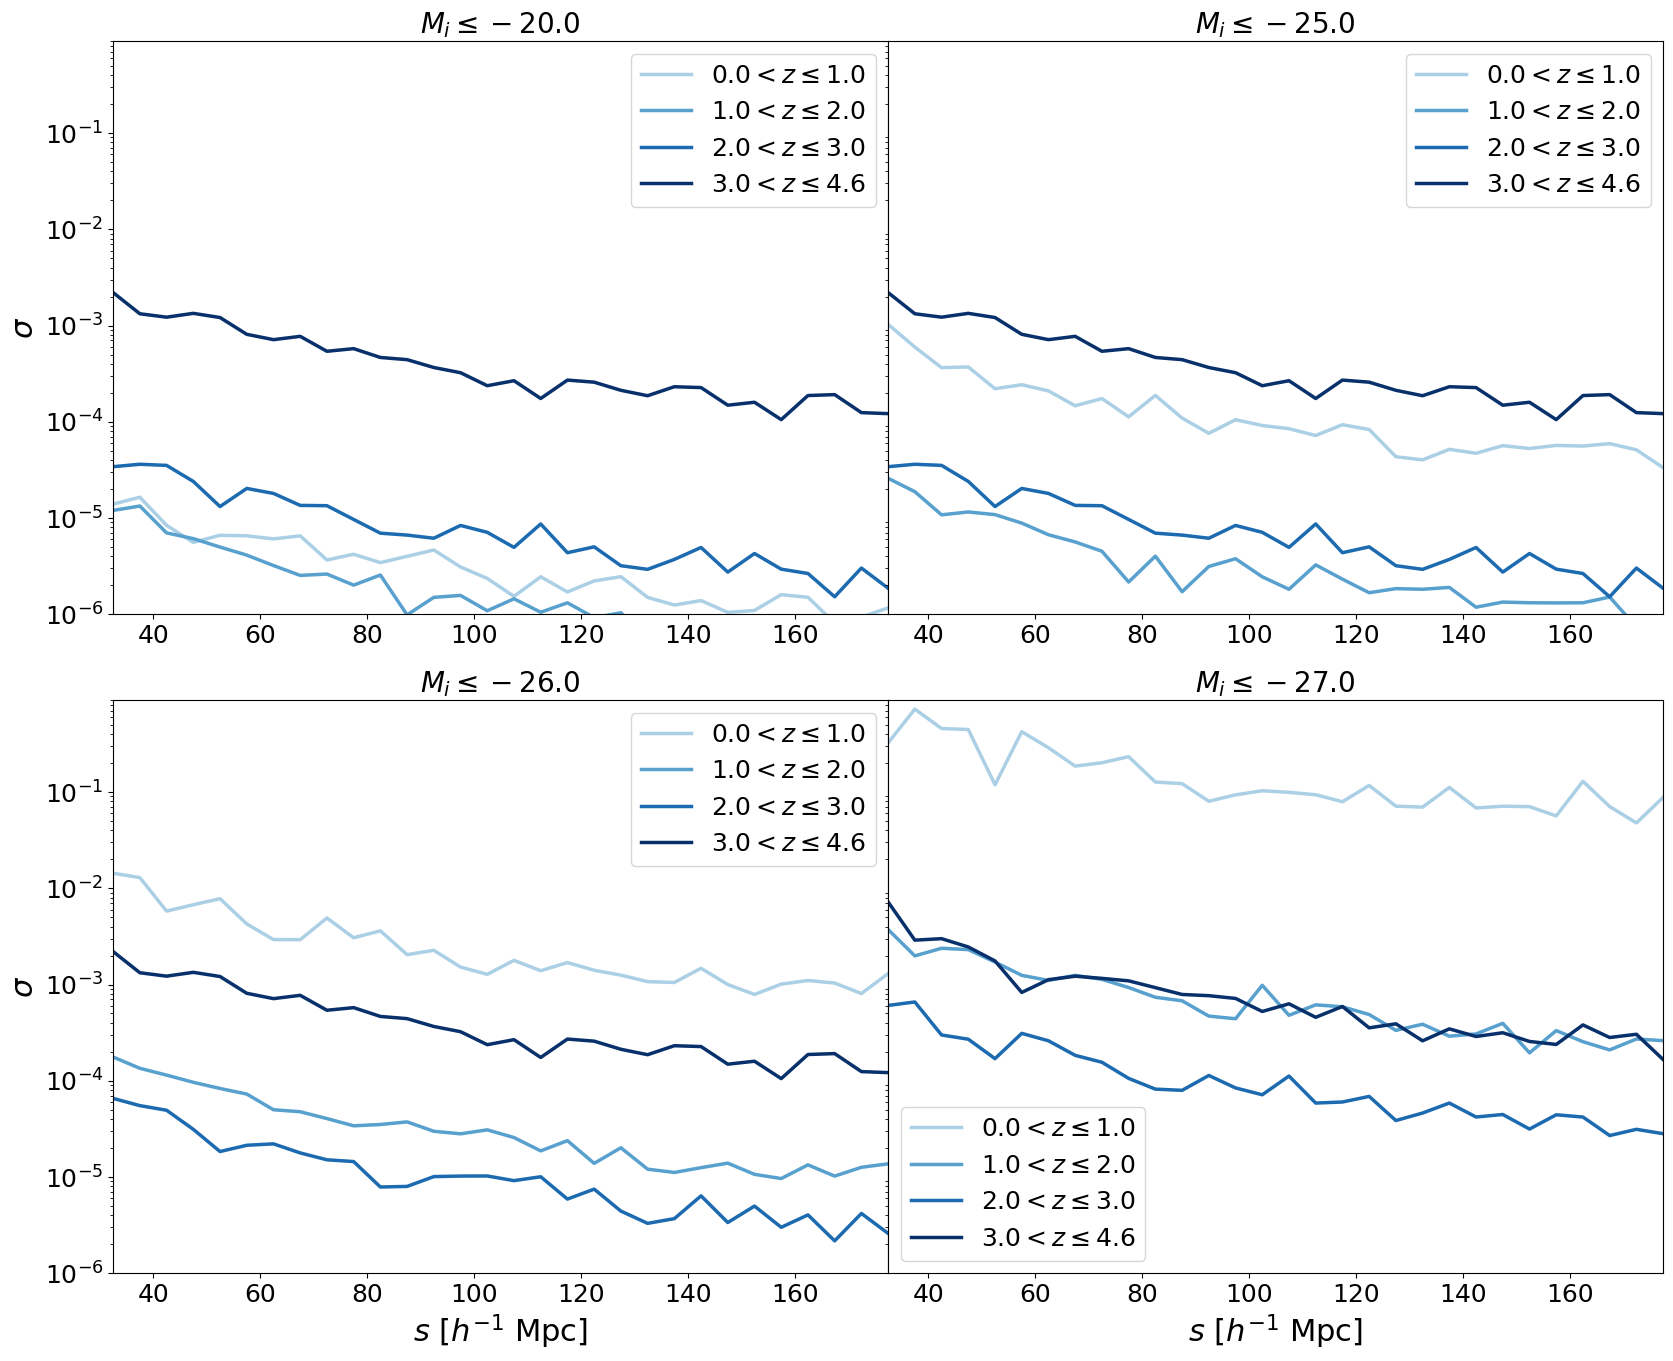

In [28]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
linestyles = ['-', '--', '-.', ':']
for i in range(len(L_bins)):

    ax1 = fig.add_subplot(gs[i])

    for j in range(len(zbin_array)-1):

        # if ((i<3) and (N_q[L_bins[i]][j]>N_q[L_bins[i+1]][j])) or (i ==3):

        var = np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[j], zbin_array[j+1], L_bins[i], N, cosmo)))
        ax1.plot(r, var, linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[j], zbin_array[j+1]), color = cmap_blue[j])

    ax1.set_xlim(r[0], r[-1])
    ax1.set_yscale('log')

    if i > 1:
        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') #
            
    if i %2 ==0:
        ax1.set_ylabel('$\sigma$')
    else:
        ax1.set_yticks([])

    ax1.set_ylim(1e-6, 9e-1)
    ax1.set_title('$M_i\leq{}$'.format(L_bins[i]))

    ax1.legend()
        
plt.show()

<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:14: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12254/3907567147.py:14: SyntaxWarning: invalid escape sequence '\l'
  ax1.plot(r, var, linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]), color = cmap_blue[j])
/tmp/ipykernel_12254/3907567147.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))


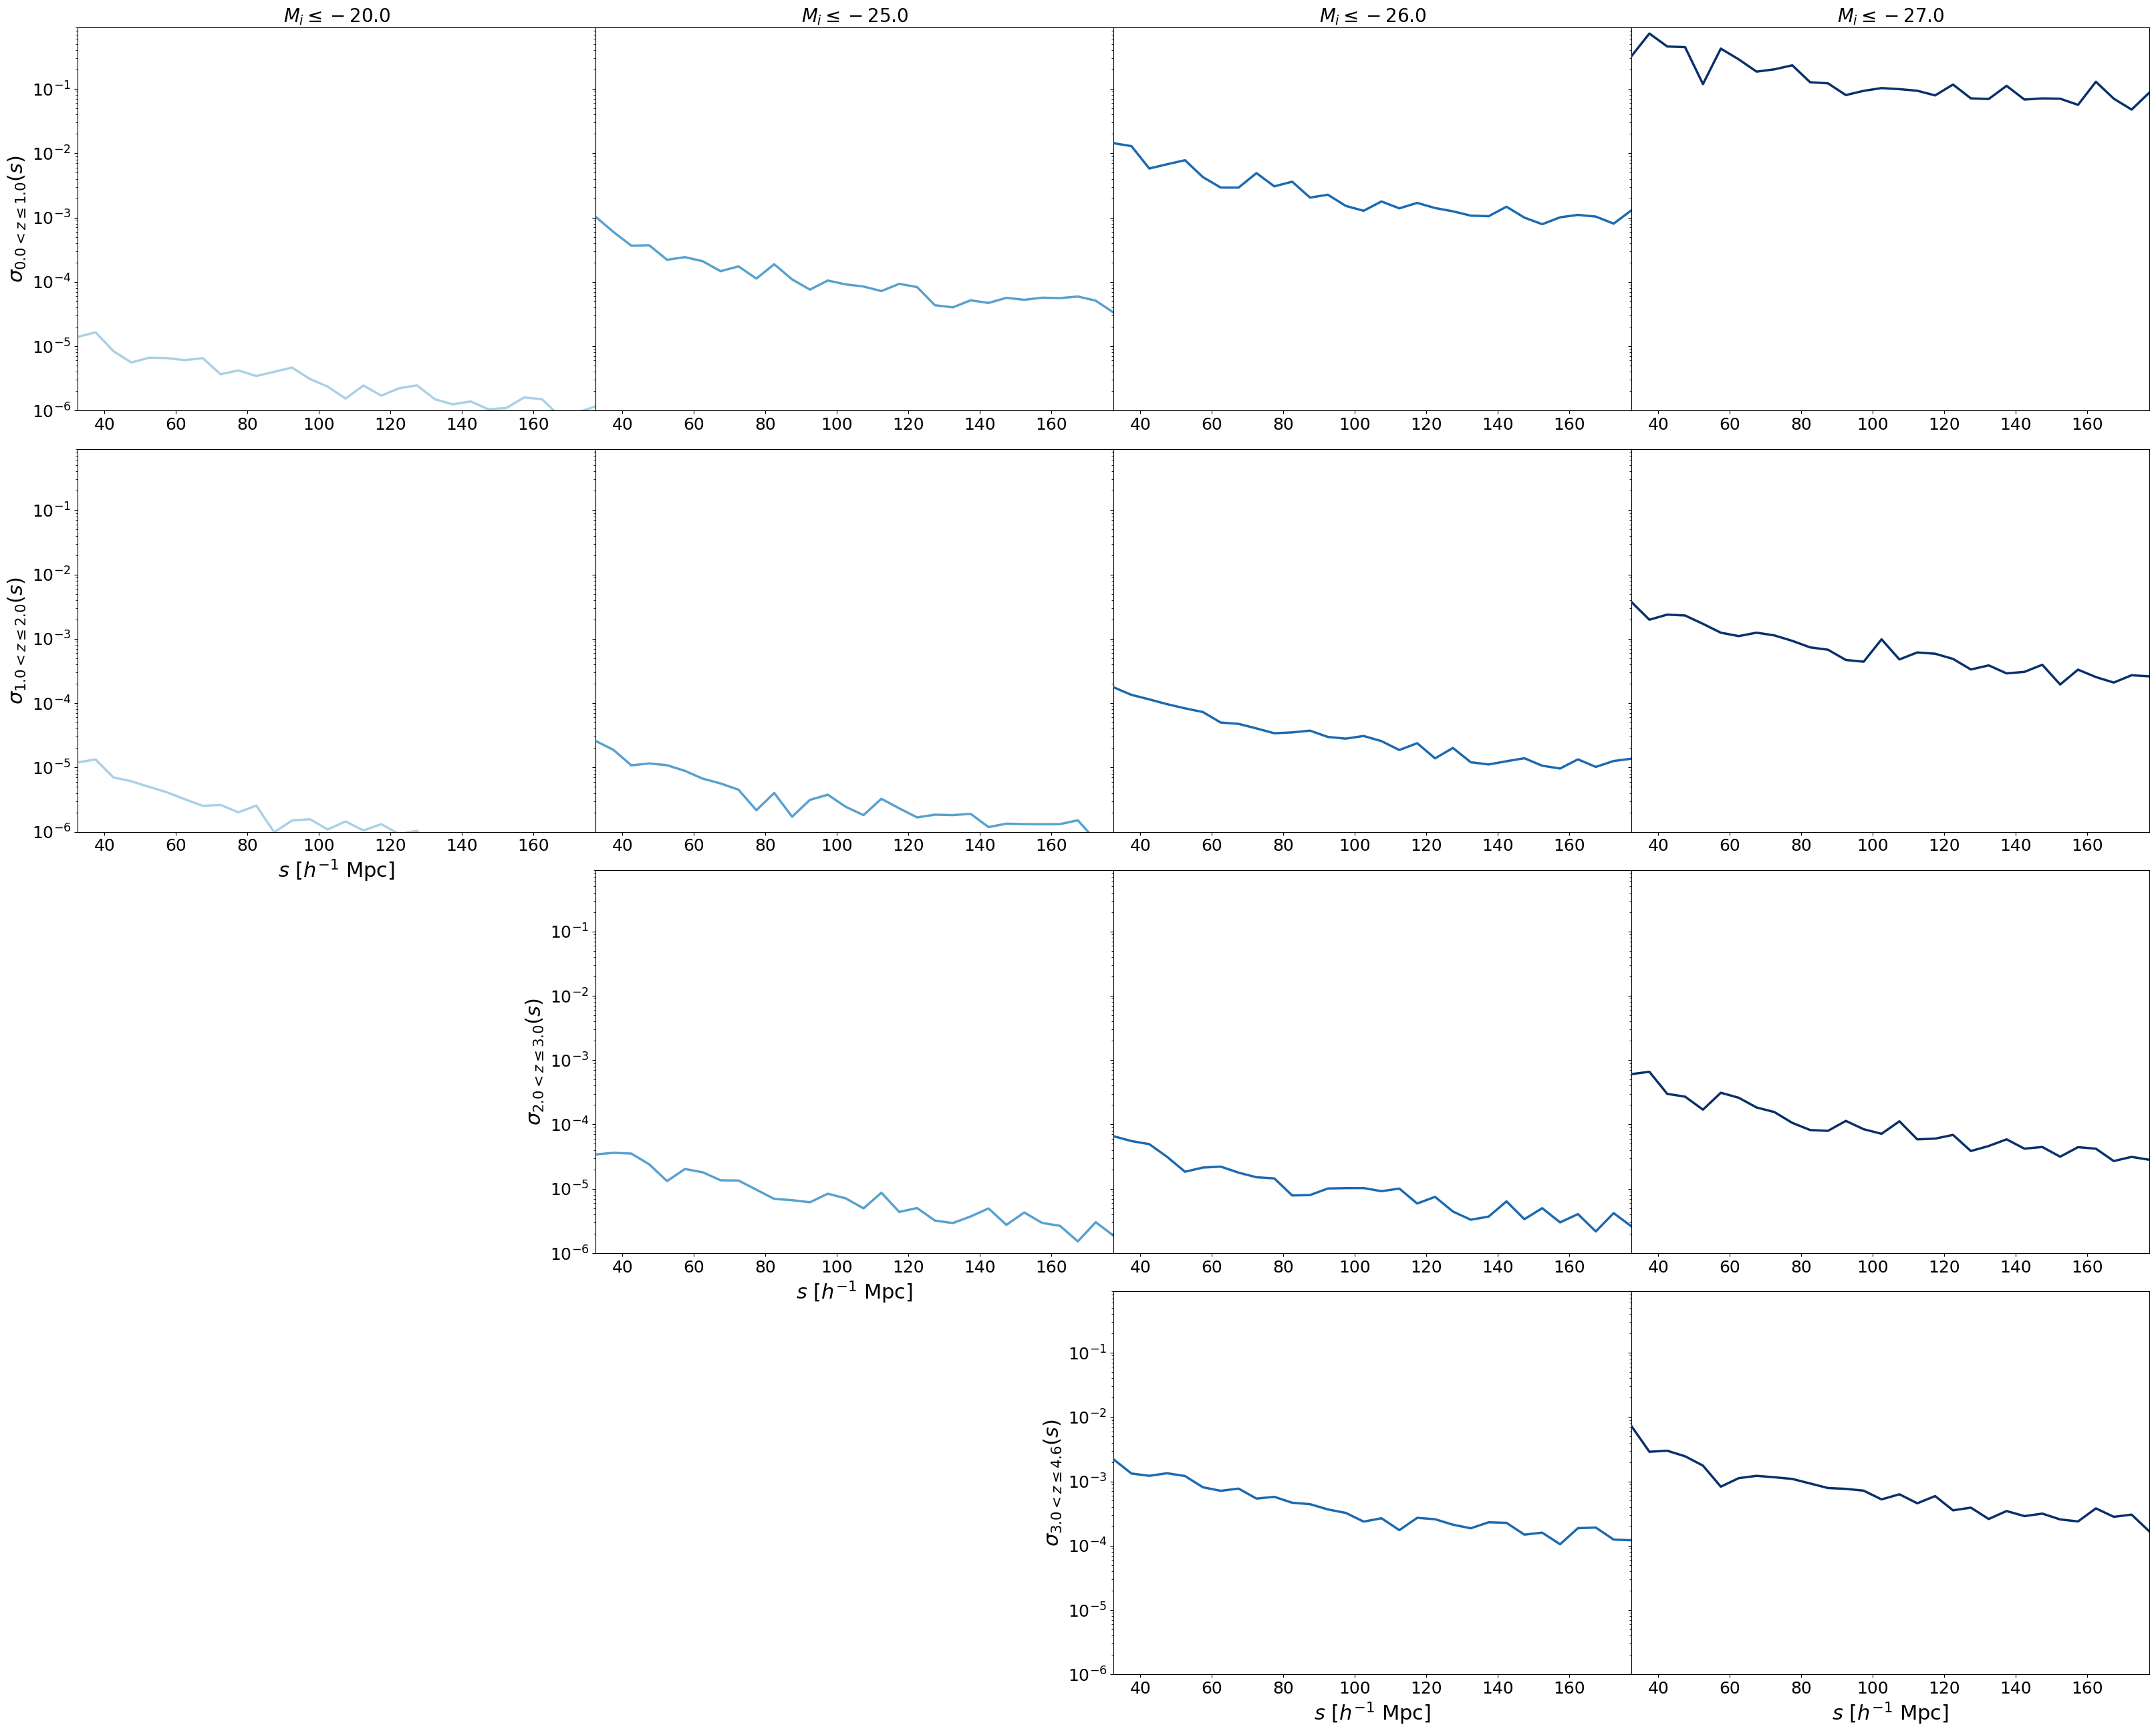

In [29]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)
ymax = [0.8, 0.1, 0.1, 0.2]
for i in range(len(zbin_array)-1):
    
    for j in range(len(L_bins)):
    
        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            ax1 = fig.add_subplot(gs[i*4+j])

            var = np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo)))
            ax1.plot(r, var, linewidth = 2.5, label = '${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]), color = cmap_blue[j])

            if i ==0:
                ax1.set_title('$M_i\leq{}$'.format(L_bins[j]))
            if scale == 'log':
                ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_xlim(r[0], r[-1])
            ax1.set_ylim(1e-6, 9e-1)
            if i > 2 or ((i>0) and (j <2) and (i!=j)):
                ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
            if j==0 or ((i>1) and (j <3) and (i!=j)):
                ax1.set_ylabel(r"$\sigma_{{{:.1f}<z \leq{:.1f}}}(s)$".format(zbin_array[i], zbin_array[i+1]))
            else:
                ax1.set_yticklabels([])

plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\l'
<>:17: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_12254/3932084845.py:17: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))


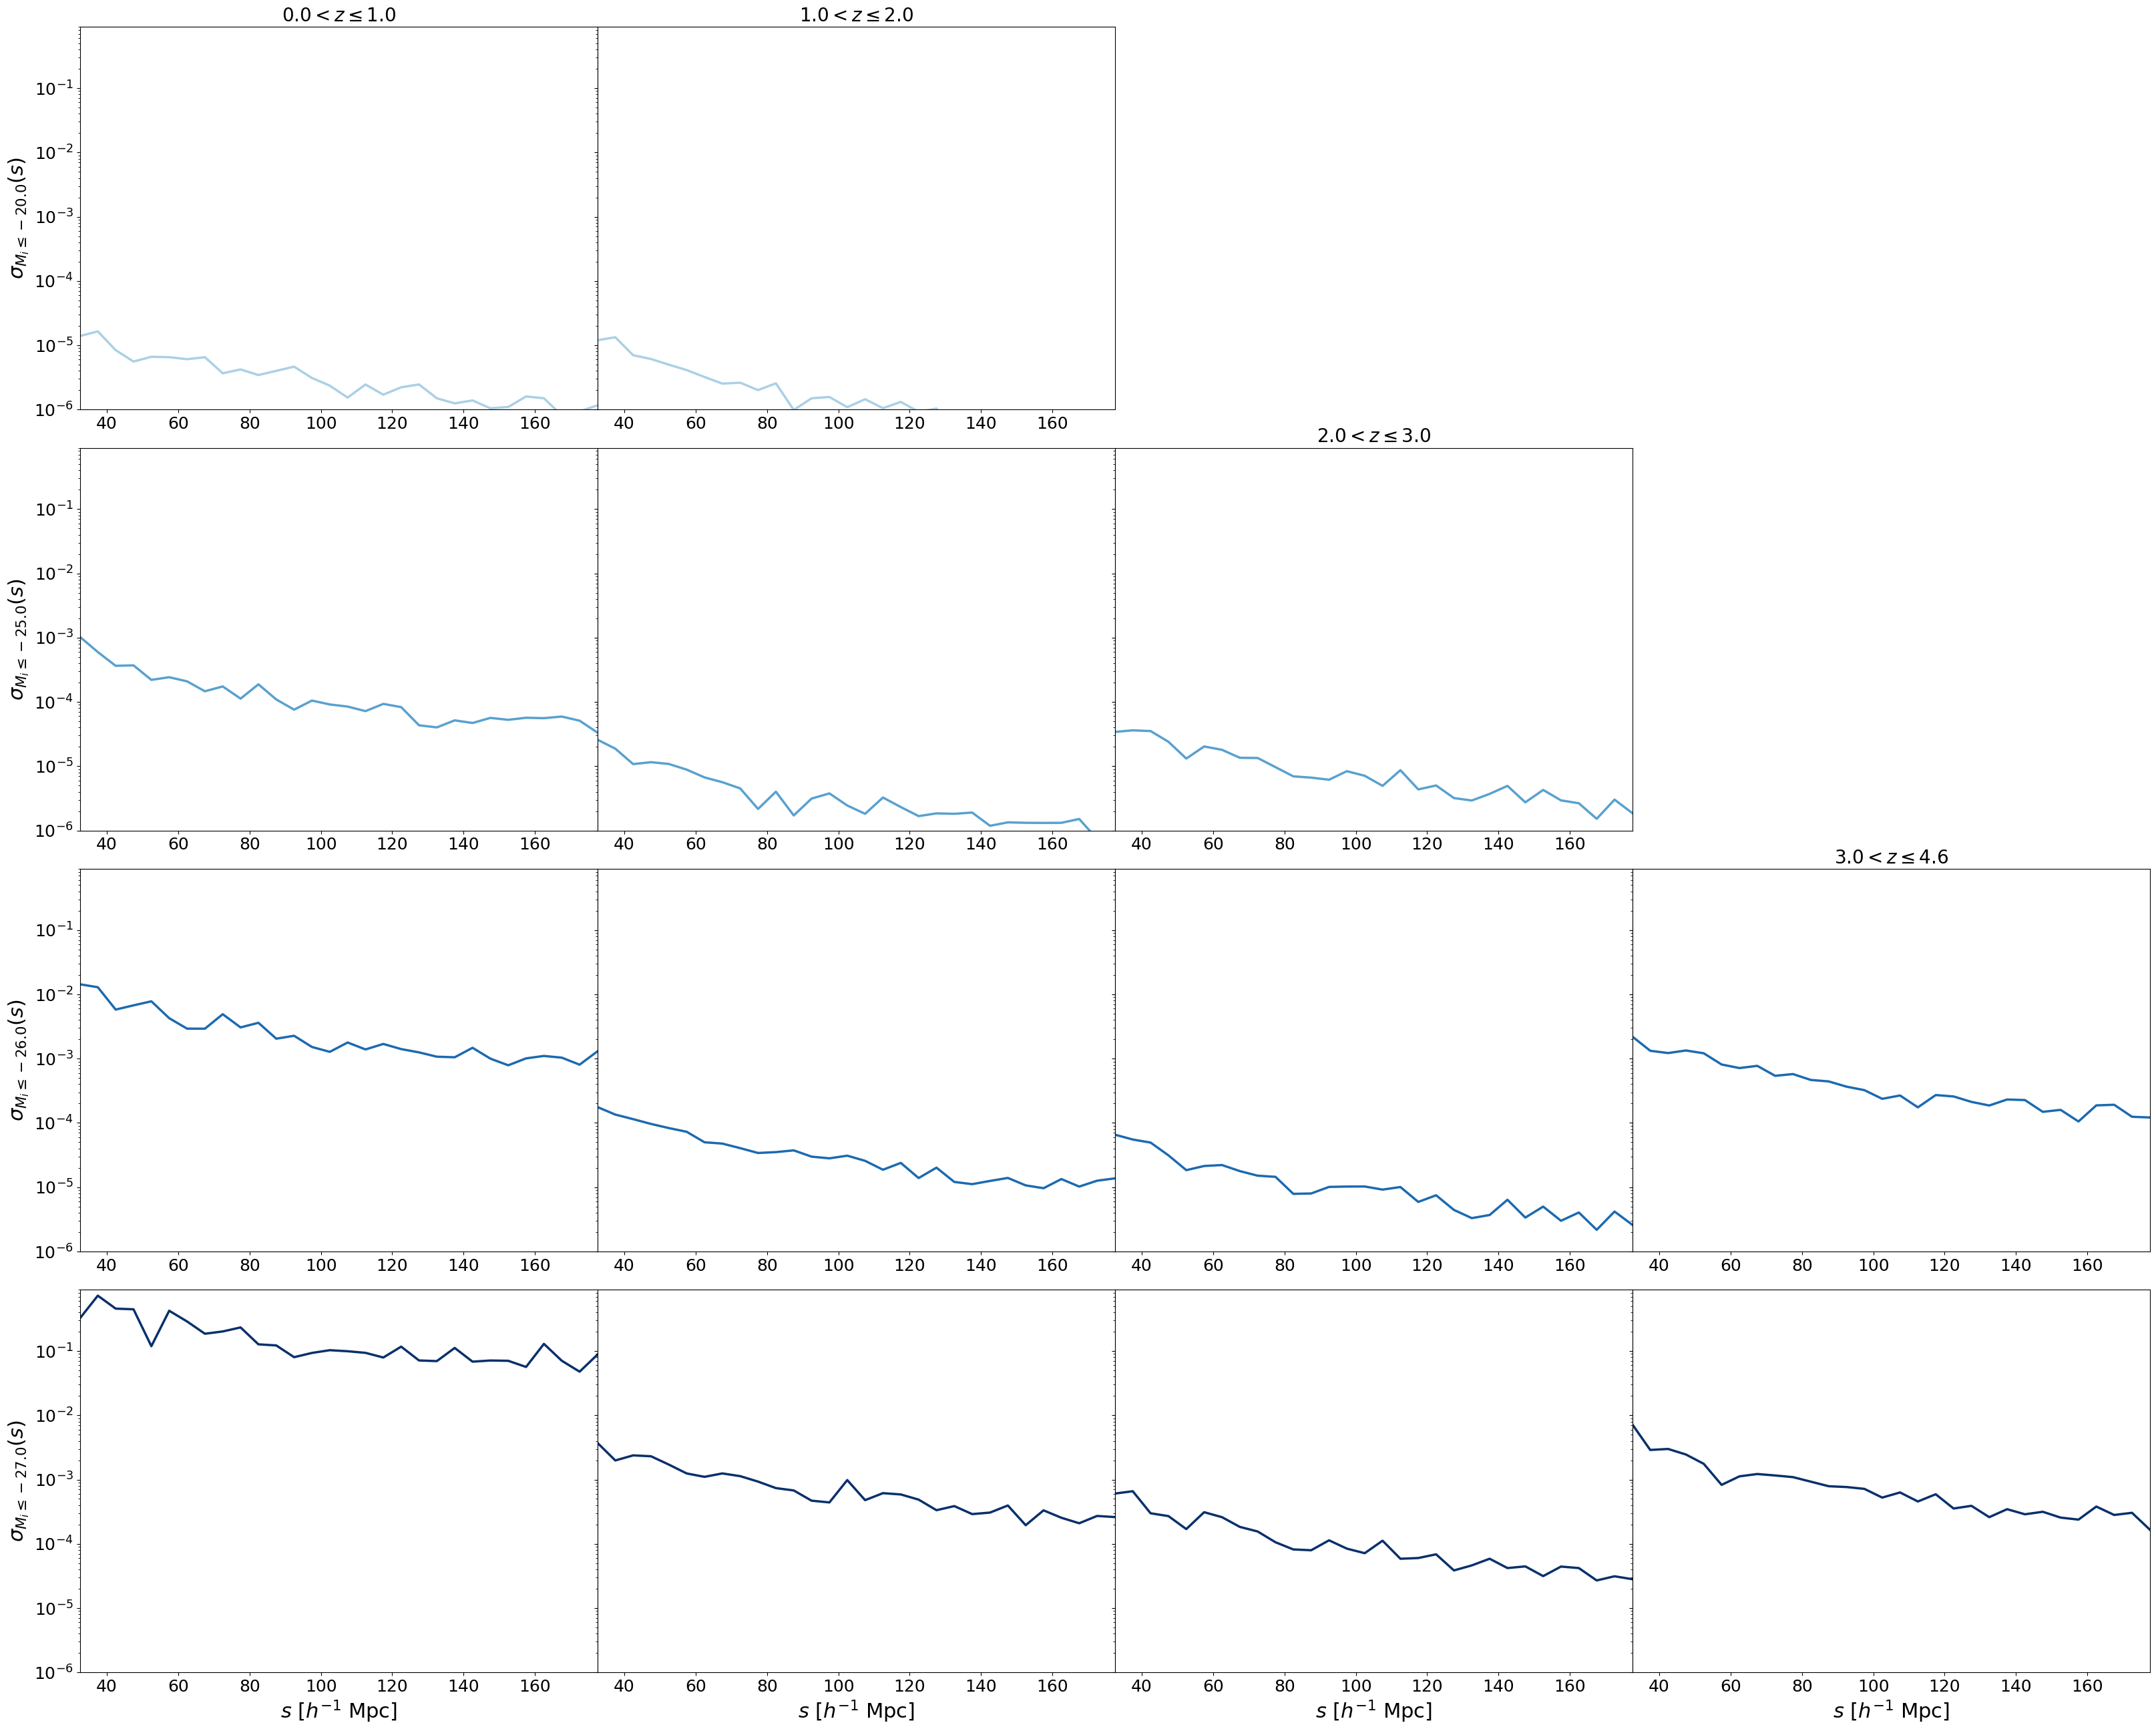

In [30]:
# plot!
fig = plt.figure(figsize = (40, 32))
gs = gridspec.GridSpec(4, 4, wspace = 0, hspace = 0.1)

for j in range(len(L_bins)):

    for i in range(len(zbin_array)-1):

        if ((j<3) and (N_q[L_bins[j]][i]>N_q[L_bins[j+1]][i])) or (j==3):

            ax1 = fig.add_subplot(gs[j*4+i])
    
            var = np.diag(np.load('../results/cov_xi_G{}_rmin{}_rmax{}_nbins{}_zmin{}zmax{}_Lmax{}_N{}_{}_MC_mask.npy'.format(G_hi, rmin, rmax, nbins, zbin_array[i], zbin_array[i+1], L_bins[j], N, cosmo)))
            ax1.plot(r, var, linewidth = 2.5, color = cmap_blue[j])
    
            if j ==0 or ((j<3) and (i>1) and (i!=j)):
                ax1.set_title('${:.1f}<z \leq{:.1f}$'.format(zbin_array[i], zbin_array[i+1]))
            if scale == 'log':
                ax1.set_xscale('log')
            ax1.set_yscale('log')
            ax1.set_xlim(r[0], r[-1])
            ax1.set_ylim(1e-6, 9e-1)
            if j > 2:
                ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]') # projected
            if i==0:
                ax1.set_ylabel(r"$\sigma_{{M_i\leq{}}}(s)$".format(L_bins[j]))
            else:
                ax1.set_yticklabels([])

plt.show()